---
---
---
# **🏭🤖🔮 Adaptive Pipeline**

![AI Sandbox Banner](../assets/adaptive-pipeline.jpg)

A modular boilerplate for building end-to-end machine learning workflows - fully customizable and extensible across different datasets and tasks.

- ✅ Dataset-Agnostic: Works with any structured dataset out of the box

- 🔧 Customizable Preprocessing: Easily define column-specific imputers, encoders, scalers, or feature engineering functions

- 📦 End-to-End Workflow: Covers data preprocessing, model training, hyperparameter tuning, evaluation, and visualization

- 📊 Clean Output: Automatically generates styled metrics tables and informative plots (ROC, PR, Confusion Matrix, Calibration, Learning Curve)

# **---------------------------------------------------------------------------------**
# **✅ A. PROJECT SETUP**

---
---
---
# **📦 A1. Import General Dependencies**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
---
---
# **⚙️ A2. Project Configurations**

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [3]:
DUMMY_MODE = True  # Set to True to use dummy data, False to use real data
ML_TYPE = 'classification'  # 'classification' or 'regression'
TARGET = 'target' if DUMMY_MODE == True else 'target_value' # Define the target variable based on the mode
TEST_SIZE = 0.2
RANDOM_SEED = 42

# **---------------------------------------------------------------------------------**
# **✅ B. DATA PIPELINE**

---
---
---
# **📥 B1. Data Collection**

--- 
### └─ **📥 Read from Scikit-learn**

In [4]:
from sklearn.datasets import fetch_california_housing, load_breast_cancer

if DUMMY_MODE == True and ML_TYPE == 'regression':
    data = fetch_california_housing(as_frame=True)
    X = data.data
    y = data.target

    df = pd.concat([X, y.rename('target')], axis=1)
    df.head()

elif DUMMY_MODE == True and ML_TYPE == 'classification':
    data = load_breast_cancer(as_frame=True)
    X = data.data
    y = data.target

    df = pd.concat([X, y.rename('target')], axis=1)
    df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
### └─ **📥 Read `CSV File`**

In [5]:
# df = pd.read_csv("your_data.csv")
# df.head()

--- 
### └─ **📥 Read `Excel File`**

- Requires `openpyxl` or `xlrd` installed

In [6]:
# df = pd.read_excel("your_data.xlsx", sheet_name='Sheet1')
# df.head()

---
### └─ **📥 Read `JSON File`**

In [7]:
# df = pd.read_json("your_data.json")
# df.head()

---
### └─ **📥 Load from `API` (JSON response)**

In [8]:
# import requests
# response = requests.get("https://api.example.com/data")
# data_json = response.json()
# df = pd.json_normalize(data_json)
# df.head()

---
### └─ **📥 Download and Read `.db` (SQLite Database) File from a Website**

In [9]:
# import requests, sqlite3
# import pandas as pd

# if ML_TYPE == 'classification':
#     # Step 1: Download the DB file
#     # url = "https://example.com/your_file.db"
#     # with open("data.db", "wb") as f:
#     #     f.write(requests.get(url).content)

#     # Step 2: Connect to DB
#     conn = sqlite3.connect("../data/example.db")

#     # Step 3: Show table names
#     tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
#     print("Tables available:", tables)

#     # Step 4: Read the first table automatically
#     first_table = tables.iloc[0, 0]  # get first table name
#     df = pd.read_sql_query(f"SELECT * FROM {first_table}", conn)
#     print(f"✅ Loaded table: {first_table} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")

#     # Step 5: Close connection
#     conn.close()

#     # Step 6: Display the first few rows of the DataFrame
#     df.head()

---
### └─ **📥 Load from a `SQL Database`**: Requires `sqlalchemy`

In [10]:
# from sqlalchemy import create_engine
# engine = create_engine('sqlite:///your_database.db')  # example: SQLite database
# df = pd.read_sql("SELECT * FROM your_table", con=engine)
# df.head()

---
### └─ **📥 Load from `Parquet File`** (efficient columnar storage)

In [11]:
# df = pd.read_parquet("your_data.parquet")
# df.head()

---
### └─ **📥 Load from a `URL`** (CSV hosted online)

In [12]:
# url = "https://example.com/data.csv"
# df = pd.read_csv(url)
# df.head()

---
### └─ **📥 Load from dictionary or other Python data structures**

In [13]:
# data_dict = {
#     'col1': [1, 2, 3],
#     'col2': ['A', 'B', 'C']
# }
# df = pd.DataFrame(data_dict)
# df.head()

---
---
---
# **🔎 B2. Basic Exploration**

---
---
## **🔎 B2.1. AutoEDA**

In [14]:
from ydata_profiling import ProfileReport

In [15]:
# # Create a profile report
# profile = ProfileReport(df, title="Profiling Report")

# # Render the profiling report directly in the notebook
# profile.to_notebook_iframe()

# # To avoid plotting issues after running the above library
# %matplotlib inline

---
---
## **🔎 B2.2. Basic Exploration**

---
### └─ **🔎 View dimensions and structure**

In [16]:
df.shape
df.info() # Datatypes and non-null counts
df.describe() # Summary statistics

(569, 31)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


---
### └─ **🔎 Preview data**

In [17]:
df.head()
df.tail()
df.sample(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
362,12.760,18.84,81.87,496.6,0.09676,0.07952,0.02688,0.01781,0.1759,0.06183,...,25.99,87.82,579.7,0.1298,0.1839,0.12550,0.08312,0.2744,0.07238,1
66,9.465,21.01,60.11,269.4,0.10440,0.07773,0.02172,0.01504,0.1717,0.06899,...,31.56,67.03,330.7,0.1548,0.1664,0.09412,0.06517,0.2878,0.09211,1
388,11.270,15.50,73.38,392.0,0.08365,0.11140,0.10070,0.02757,0.1810,0.07252,...,18.93,79.73,450.0,0.1102,0.2809,0.30210,0.08272,0.2157,0.10430,1
396,13.510,18.89,88.10,558.1,0.10590,0.11470,0.08580,0.05381,0.1806,0.06079,...,27.20,97.33,675.2,0.1428,0.2570,0.34380,0.14530,0.2666,0.07686,1
318,9.042,18.90,60.07,244.5,0.09968,0.19720,0.19750,0.04908,0.2330,0.08743,...,23.40,68.62,297.1,0.1221,0.3748,0.46090,0.11450,0.3135,0.10550,1


---
### └─ **🔎 Data missingness**

In [18]:
df.isnull().sum().sort_values(ascending=False)

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

<Figure size 1000x600 with 0 Axes>

<Axes: >

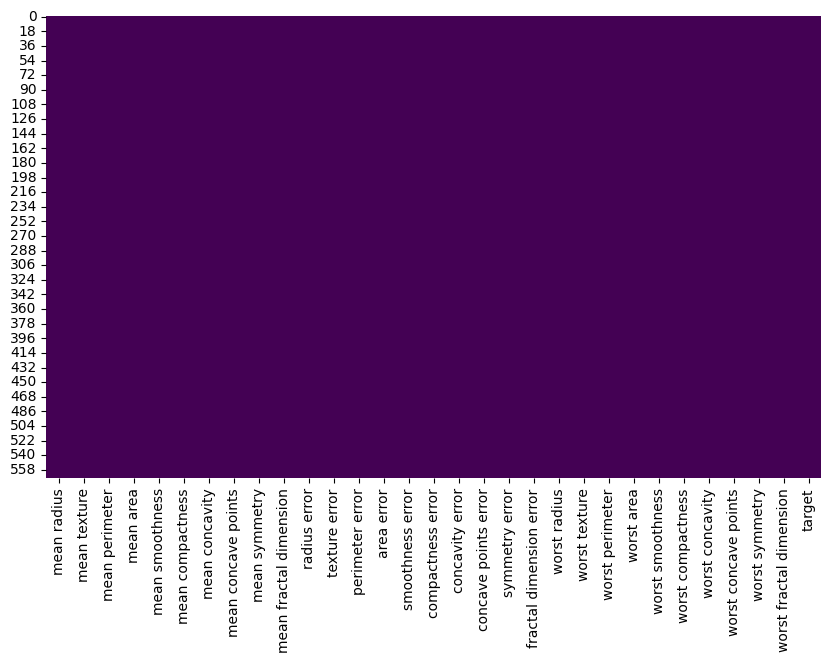

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

---
---
## **🔎 B2.3. Univariate Analysis**

In [20]:
from univariate_analysis import perform_univariate_analysis

In [104]:
# Generate synthetic dataset
np.random.seed(42)
n = 300

df_plots = pd.DataFrame({
    'age': np.random.normal(35, 10, n).astype(int),
    'income': np.random.normal(50000, 15000, n).astype(int),
    'gender': np.random.choice(['Male', 'Female'], n),
    'purchased': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7])
})

In [108]:
df_plot_feature = 'age'

---
### └─ **🔎 Consolidated function**

🔢 Data Type: int64
💎 Number of Unique Values: 47
📋 List of Unique Categories: [39, 33, 41, 50, 32, 42, 30, 40, 37, 15, 17, 29, 24, 38, 25, 20, 49, 35, 36, 23, 28, 53, 34, 43, 22, 21, 31, 27, 45, 44, 26, 48, 8, 59, 46, 56, 19, 18, 62, 73, 58, 16, 14, 52, 47, 2, 51]
📊 Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
age,300.00,34.41,9.87,2.00,28.00,35.00,41.00,73.00


📈 Data Distribution: 
   └── Skewness: 0.17 
   └── Kurtosis: 0.59 

🔍 Outlier Detection Method: Using IQR (Interquartile Range)
   └── Reason: High skewness or kurtosis suggests non-normal distribution.
   └── ⚠️ 4 outliers detected (1.33% of total rows).
   └── Lower Bound: 8.50
   └── Upper Bound: 60.50
   └── Outliers Summary:


,age
count,4.00
mean,36.25
std,36.45
min,2.00
25%,6.50
50%,35.00
75%,64.75
max,73.00



✅ No missing values found.


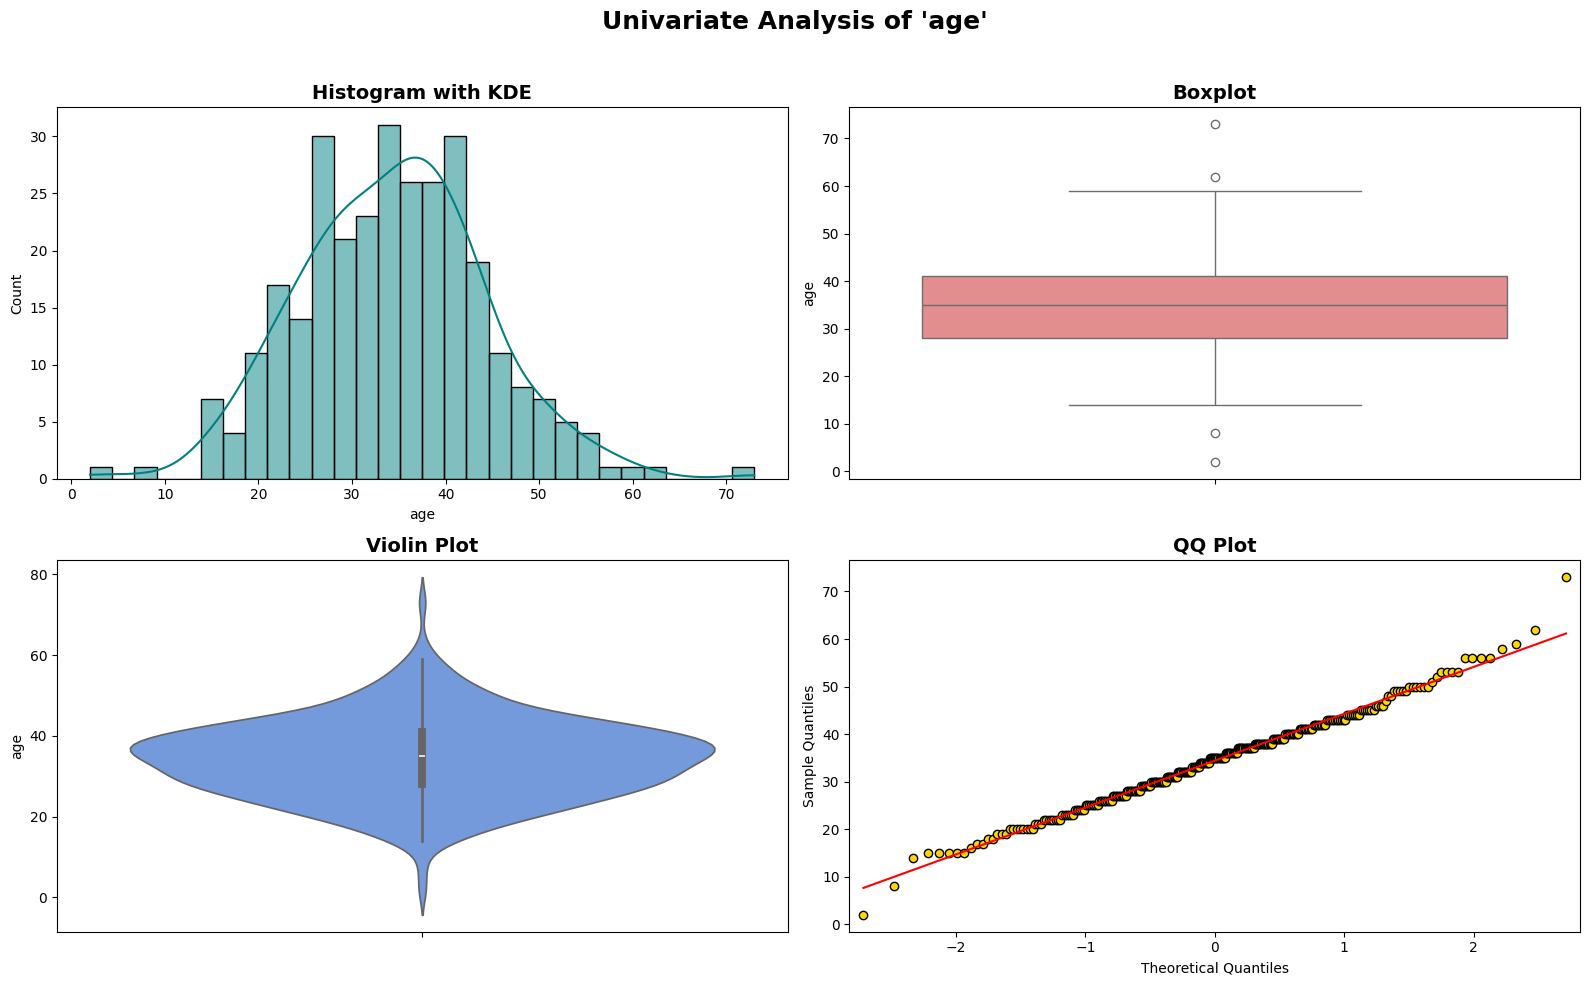

In [109]:
perform_univariate_analysis(df_plots, df_plot_feature, show_distribution=False)

---
### └─ **🔎 Numerical**

In [159]:
# Descriptive statistics
df[['age', 'income']].describe()

# Skewness: asymmetry of the distribution
df[['age', 'income']].skew()

# Kurtosis: tail heaviness
df[['age', 'income']].kurt()

,age,income
count,300.000000,300.000000
mean,34.413333,49677.140000
std,9.872218,14424.279149
min,2.000000,12925.000000
25%,28.000000,39433.750000
50%,35.000000,49718.000000
75%,41.000000,59244.500000
max,73.000000,96183.000000


age       0.168741
income    0.134345
dtype: float64

age       0.589480
income   -0.075365
dtype: float64

---
### └─ **🔎 Categorical**

In [154]:
# Frequency counts
df['gender'].value_counts()

# Frequency with normalized percentages
df['purchased'].value_counts(normalize=True) * 100

# Unique values
df['gender'].unique()

# Mode (most frequent value)
df['purchased'].mode()[0]


gender
Male      154
Female    146
Name: count, dtype: int64

purchased
No     69.0
Yes    31.0
Name: proportion, dtype: float64

array(['Male', 'Female'], dtype=object)

'No'

---
---
## **🔎 B2.4. Univariate Plots (N)**

---
### └─ **📊 Histogram**

**🎯 Purpose**

- Visualize the distribution of a single numeric variable by grouping data into bins.
- Reveal shape, central tendency, spread, skewness, and outliers.
- Aid exploratory data analysis and guide data transformations.


| **✅ When to Use**                                                    | **❌ When Not to Use**                                         |
|-------------------------------------------------------------------|-------------------------------------------------------------|
| To understand the distribution of continuous or discrete numeric data. | With categorical variables (use bar charts instead).        |
| When sample size is large enough for meaningful patterns.         | On very small datasets where results may be misleading.     |
| For comparing distributions across groups or datasets.            | When exploring relationships between multiple variables.    |
| To detect skewness, modality, and outliers in data.               | Without careful bin size choice — too big oversimplifies; too small adds noise. |

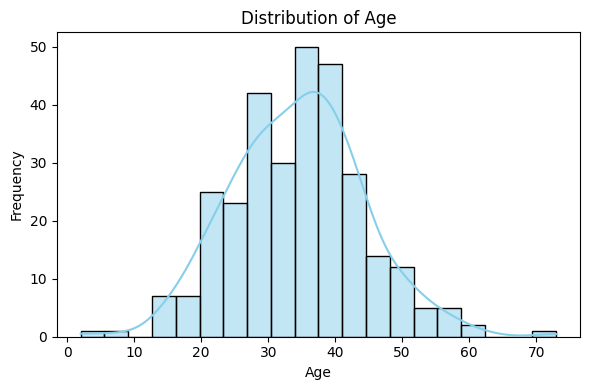

In [114]:
plt.figure(figsize=(6,4))
sns.histplot(df_plots['age'], kde=True, bins=20, color='skyblue')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show();

---
### └─ **📦 Box Plot**

**🎯 Purpose**

- Summarize the distribution of a numeric variable through key statistics: median, quartiles, and extremes.
- Detect outliers and visualize data spread and symmetry.
- Compare distributions across different categories.

| **✅ When to Use**                                               | **❌ When Not to Use**                                            |
|--------------------------------------------------------------|----------------------------------------------------------------|
| To understand central tendency, variability, and skewness.  | For categorical variables without a meaningful order.          |
| When you want to easily identify outliers.                   | When sample size is extremely small (may not represent true distribution). |
| For comparing numeric distributions across groups or categories. | When precise individual data points need to be visualized (use strip or swarm plots instead). |
| When dealing with continuous or discrete numeric data.       | If you need detailed information about distribution shape beyond quartiles (consider histograms or KDE plots). |


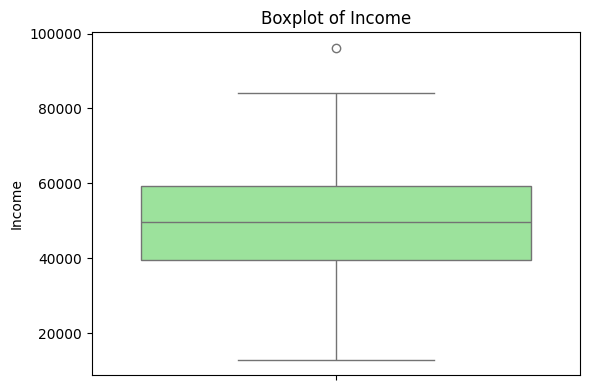

In [113]:
plt.figure(figsize=(6,4))
sns.boxplot(y='income', data=df_plots, color='lightgreen')
plt.title("Boxplot of Income")
plt.ylabel("Income")
plt.tight_layout()
plt.show();

---
### └─ **🎻 Violin Plot**

**🎯 Purpose**

- Visualize the distribution of a numeric variable, showing its density and probability shape.
- Combine features of boxplots and kernel density estimation to reveal spread, modality, and skewness.
- Compare distributions across different categories with more detail than a boxplot.

| **✅ When to Use**                                                | **❌ When Not to Use**                                                                   |
| ---------------------------------------------------------------- | --------------------------------------------------------------------------------------- |
| To explore detailed distribution shapes including multimodality. | For small datasets where density estimation is unreliable.                              |
| When you want to compare numeric distributions across groups.    | For categorical variables without numeric data.                                         |
| To visualize both summary statistics and distribution shape.     | When simple summary statistics are sufficient (boxplot may suffice).                    |
| When dealing with continuous or discrete numeric data.           | When clarity is more important than detailed distribution shape (boxplots are simpler). |


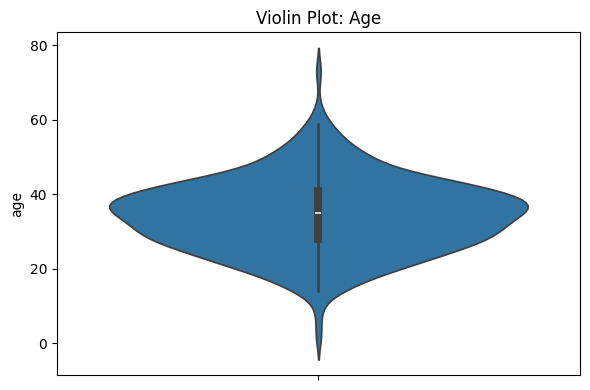

In [149]:
plt.figure(figsize=(6, 4))
sns.violinplot(y='age', data=df_plots)
plt.title("Violin Plot: Age")
plt.tight_layout()
plt.show();

---
### └─ **📈 KDE Plot**

**🎯 Purpose**

- Estimate and visualize the probability density function of a continuous numeric variable.
- Show smooth distribution shapes without binning (unlike histograms).
- Help identify modality, skewness, and spread in data.
- Useful for comparing distributions between groups.

| **✅ When to Use**                                               | **❌ When Not to Use**                                                |
| --------------------------------------------------------------- | -------------------------------------------------------------------- |
| To explore smooth distribution shapes of continuous data.       | For very small datasets where density estimates are unreliable.      |
| When you want a continuous, smoothed alternative to histograms. | For categorical or discrete variables without meaningful continuity. |
| To compare distributions across different groups.               | When exact counts or frequencies are needed (use histograms).        |
| When interested in identifying multiple modes or skewness.      | When interpretability and simplicity are priorities (use boxplots).  |


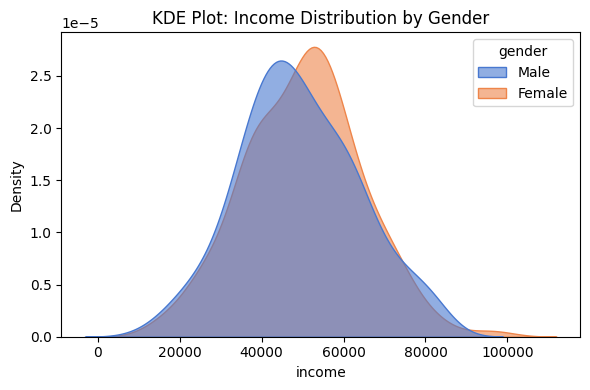

In [129]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df_plots, x='income', hue='gender', fill=True, common_norm=False, palette='muted', alpha=0.6)
plt.title("KDE Plot: Income Distribution by Gender")
plt.tight_layout()
plt.show();

---
---
## **🔎 B2.4. Univariate Plots (C)**

---
### └─ **📊 Bar Plot**

**🎯 Purpose**

- Visualize the summary (typically count or average) of a categorical variable or numeric variable grouped by categories.
- Compare values across discrete groups or categories clearly.
- Show aggregated statistics like mean, sum, or count per category.

| **✅ When to Use**                                            | **❌ When Not to Use**                                                                          |
| ------------------------------------------------------------ | ---------------------------------------------------------------------------------------------- |
| To compare counts or summary statistics across categories.   | For continuous variables without grouping (use histograms or scatter plots).                   |
| When you want to visualize categorical data distributions.   | When sample sizes are too small for meaningful category comparisons.                           |
| To display aggregated numeric values by groups.              | When individual data points or distribution shapes matter more (use boxplots or violin plots). |
| When you want a simple, intuitive comparison between groups. | When you need to show relationships between two continuous variables (use scatterplots).       |


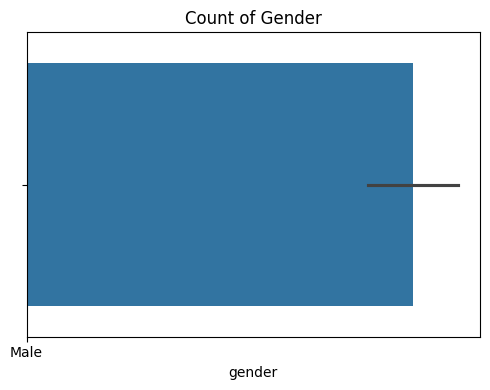

In [134]:
plt.figure(figsize=(5,4))
sns.barplot(x='gender', data=df_plots)
plt.title("Count of Gender")
plt.tight_layout()
plt.show();

---
### └─ **🥧 Pie Chart**

**🎯 Purpose**

- Show proportions or percentages of categories as slices of a whole.
- Provide a visual sense of relative sizes of parts within a total.
- Useful for displaying simple categorical composition.

| **✅ When to Use**                                       | **❌ When Not to Use**                                                       |
| ------------------------------------------------------- | --------------------------------------------------------------------------- |
| To illustrate percentage or proportion of categories.   | When there are too many categories (makes slices hard to read).             |
| When you want an intuitive, visual breakdown of parts.  | When precise comparisons between categories are needed (use bar plots).     |
| For small numbers of categories with clear differences. | When categories have very similar sizes (pie slices look nearly identical). |
| When total adds up to a meaningful whole (e.g., 100%).  | When you need to display relationships between multiple variables.          |


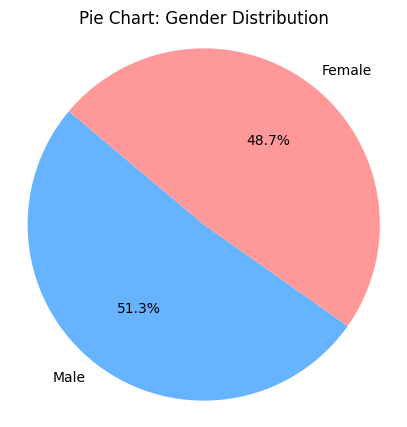

In [130]:
gender_counts = df_plots['gender'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=140)
plt.title("Pie Chart: Gender Distribution")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show();

---
### └─ **🍩 Donut Chart**

**🎯 Purpose**

- Similar to pie charts, show proportions or percentages of categories as slices of a whole.
- Add a blank center for aesthetic appeal or to display additional information.
- Useful for highlighting parts of a whole with a modern look.

| **✅ When to Use**                                                    | **❌ When Not to Use**                                                              |
| -------------------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| To illustrate category proportions with a visually appealing design. | When there are too many categories, making slices hard to distinguish.             |
| When you want to emphasize the whole and parts simultaneously.       | When precise numeric comparisons between categories are necessary (use bar plots). |
| For small numbers of distinct categories with clear differences.     | When category sizes are very similar, making slices indistinguishable.             |
| When adding central text or labels enhances understanding.           | When displaying relationships between multiple variables.                          |


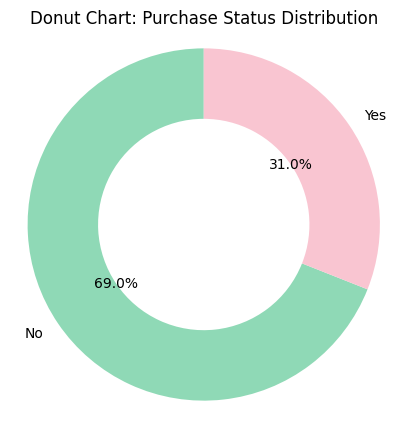

In [131]:
purchase_counts = df_plots['purchased'].value_counts()

plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(
    purchase_counts,
    labels=purchase_counts.index,
    autopct='%1.1f%%',
    colors=['#8fd9b6', '#f9c5d1'],
    startangle=90,
    wedgeprops=dict(width=0.4)  # This creates the "donut hole"
)
plt.title("Donut Chart: Purchase Status Distribution")
plt.axis('equal')
plt.show();

---
### └─ **📋 Count Plot**

**🎯 Purpose**

- Visualize the frequency (count) of each category in a categorical variable.
- Provide a straightforward way to see how data points are distributed across categories.
- Ideal for understanding class imbalance or distribution.

| **✅ When to Use**                                              | **❌ When Not to Use**                                                            |
| -------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| To quickly see counts of categories in a dataset.              | When dealing with continuous variables (use histograms instead).                 |
| When checking class balance for classification problems.       | When you need to visualize relationships between multiple variables.             |
| For simple categorical data distribution analysis.             | When sample sizes per category are extremely small or categories are too many.   |
| When you want an easy-to-interpret categorical frequency plot. | When precise numerical summaries or comparisons are needed (consider bar plots). |


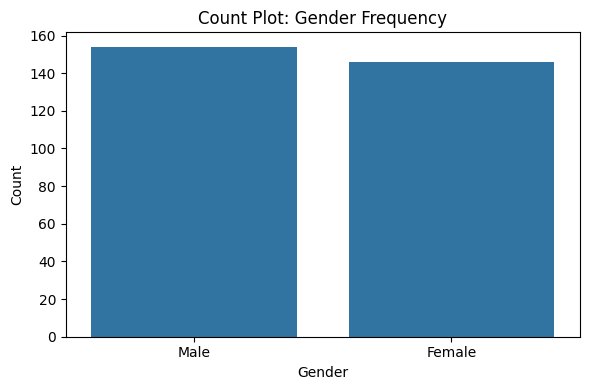

In [133]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_plots, x='gender')
plt.title("Count Plot: Gender Frequency")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show();

---
---
## **🔎 B2.3. Bivariate Analysis**

---
### └─ **🔎 Numerical vs Numerical**

In [155]:
# Correlation matrix
df[['age', 'income']].corr()

# Covariance matrix
df[['age', 'income']].cov()

,age,income
age,1.000000,-0.039757
income,-0.039757,1.000000


,age,income
age,97.460691,-5.661419e+03
income,-5661.419264,2.080598e+08


---
### └─ **🔎 Numerical vs Categorical**

In [156]:
# Grouped summary statistics
df.groupby('gender')['income'].describe()

# Grouped means
df.groupby('purchased')['age'].mean()


,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,146.0,50219.506849,14232.127069,15471.0,39588.5,50715.5,58857.25,96183.0
Male,154.0,49162.948052,14631.860601,12925.0,39094.0,47697.0,59595.50,82847.0


purchased
No     34.338164
Yes    34.580645
Name: age, dtype: float64

---
### └─ **🔎 Categorical vs Categorical**

In [157]:
# Contingency table (cross-tabulation)
pd.crosstab(df['gender'], df['purchased'])

# Normalized proportions (row-wise)
pd.crosstab(df['gender'], df['purchased'], normalize='index') * 100


purchased,No,Yes
gender,,
Female,95,51
Male,112,42


purchased,No,Yes
gender,,
Female,65.068493,34.931507
Male,72.727273,27.272727


---
---
## **🔎 B2.5. Bivariate Plots (NN)**

---
### └─ **♦️ Scatterplot**

**🎯 Purpose**

- Visualize the relationship between two continuous numeric variables.
- Identify patterns, trends, clusters, or outliers in data.
- Useful for detecting correlations and distributions.

| **✅ When to Use**                                                       | **❌ When Not to Use**                                                                        |
| ----------------------------------------------------------------------- | -------------------------------------------------------------------------------------------- |
| To explore relationships or associations between two numeric variables. | When variables are categorical or discrete (use bar or count plots).                         |
| When you want to detect trends, clusters, or outliers.                  | For large datasets where overplotting obscures patterns (use hexbin or density plots).       |
| To check assumptions for regression or correlation analysis.            | When precise counts or distributions are more important than relationships (use histograms). |
| When you want a visual summary of paired numeric data points.           | When one variable is categorical and better shown with boxplots or violin plots.             |


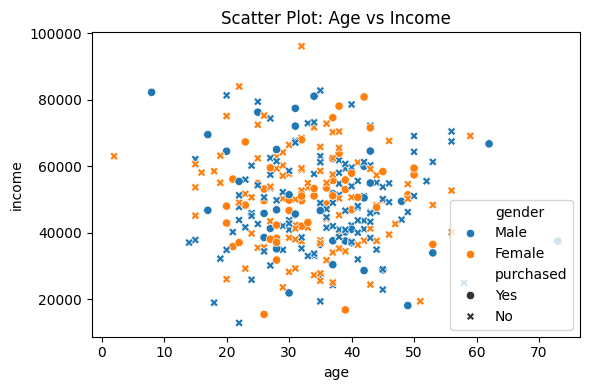

In [120]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='income', data=df, hue='gender', style='purchased')
plt.title("Scatter Plot: Age vs Income")
plt.tight_layout()
plt.show();

---
### └─ **💠 Hexbin Plot**

**🎯 Purpose**

- Visualize the relationship between two continuous numeric variables using hexagonal binning.
- Handle large datasets by aggregating points into hexagonal bins to reduce overplotting.
- Show density of data points with color intensity indicating concentration.

| **✅ When to Use**                                                        | **❌ When Not to Use**                                                       |
| ------------------------------------------------------------------------ | --------------------------------------------------------------------------- |
| To explore relationships in large datasets with many overlapping points. | When dataset is small and scatter plots can show individual points clearly. |
| When you want to identify dense clusters or data concentrations.         | For categorical variables or small sample sizes.                            |
| To reduce overplotting issues in scatter plots.                          | When exact point locations are critical (scatter plots preferred).          |
| When analyzing continuous numeric variables on both axes.                | When data is discrete or categorical (use bar or count plots).              |


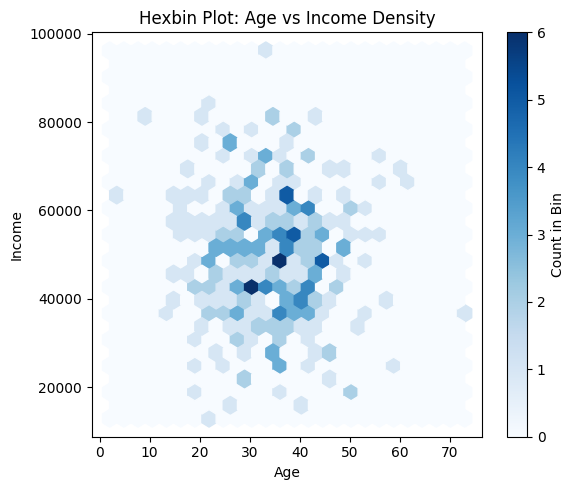

In [136]:
# Hexbin Plot: Age vs Income
plt.figure(figsize=(6, 5))
plt.hexbin(df_plots['age'], df_plots['income'], gridsize=25, cmap='Blues')
plt.colorbar(label='Count in Bin')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Hexbin Plot: Age vs Income Density')
plt.tight_layout()
plt.show();

---
### └─ **📈 Line Plot**

**🎯 Purpose**

- Visualize trends and changes of a numeric variable over a continuous or ordered variable (often time).
- Show how one variable evolves in relation to another, highlighting patterns and fluctuations.
- Useful for time series data and sequential observations.

| **✅ When to Use**                                                 | **❌ When Not to Use**                                                   |
| ----------------------------------------------------------------- | ----------------------------------------------------------------------- |
| To track changes and trends over time or ordered categories.      | When variables are categorical without meaningful order.                |
| When visualizing continuous data points connected sequentially.   | For non-sequential data without clear order (use scatter plots).        |
| To compare multiple series or groups across an ordered variable.  | When data is sparse or irregularly spaced (may mislead interpretation). |
| When highlighting overall direction, seasonal effects, or cycles. | When you need to display detailed distributions or individual values.   |


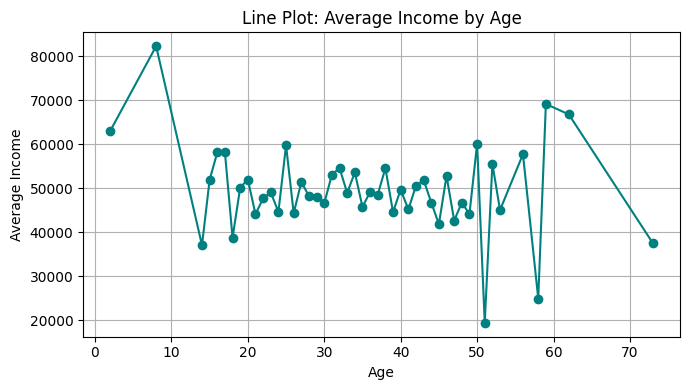

In [137]:
# Line Plot: Average income by age
avg_income_by_age = df_plots.groupby('age')['income'].mean().sort_index()

plt.figure(figsize=(7, 4))
plt.plot(avg_income_by_age.index, avg_income_by_age.values, marker='o', linestyle='-', color='teal')
plt.xlabel('Age')
plt.ylabel('Average Income')
plt.title('Line Plot: Average Income by Age')
plt.grid(True)
plt.tight_layout()
plt.show();

---
---
## **🔎 B2.5. Bivariate Plots (CN)**

---
### └─ **📦 Box Plot (Bivariate)**

**🎯 Purpose**

- Compare the distribution of a numeric variable across different categories of another variable.
- Summarize central tendency, spread, skewness, and detect outliers within groups.
- Facilitate visual group comparisons in bivariate categorical-numeric data.

| **✅ When to Use**                                                          | **❌ When Not to Use**                                                                                 |
| -------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------- |
| To compare distributions of a numeric variable between groups.             | When categories have very few data points (box plot may be misleading).                               |
| When identifying differences in median, spread, or outliers across groups. | When detailed individual data points are needed (use swarm or strip plots).                           |
| When exploring group-based variations and spotting anomalies.              | For purely categorical data without numeric variables.                                                |
| When summarizing and comparing multiple groups visually.                   | When data distributions are very complex and require detailed shape analysis (consider violin plots). |


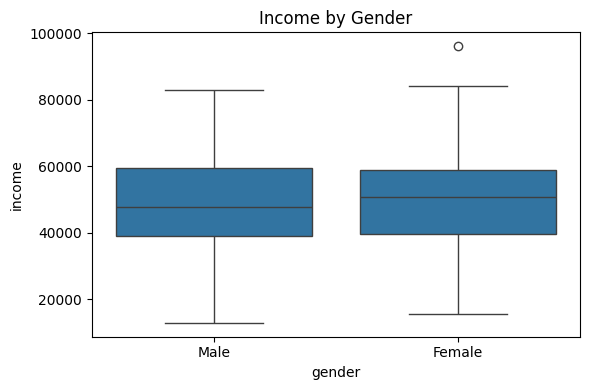

In [122]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='income', data=df)
plt.title("Income by Gender")
plt.tight_layout()
plt.show();

---
### └─ **🎻 Violin Plot (Bivariate)**

**🎯 Purpose**

- Visualize the distribution and density of a numeric variable across categories of another variable.
- Combine features of boxplots and kernel density estimation to show data spread, modality, and outliers within groups.
- Facilitate detailed comparison of distributions between groups.

| **✅ When to Use**                                                    | **❌ When Not to Use**                                                      |
| -------------------------------------------------------------------- | -------------------------------------------------------------------------- |
| To explore detailed distribution shapes across different categories. | When sample size per group is too small for reliable density estimation.   |
| When comparing numeric variable distributions between groups.        | For purely categorical data without numeric variables.                     |
| To reveal multimodality, skewness, and outliers within groups.       | When simplicity and quick summary statistics are preferred (use boxplots). |
| When detailed visualization of distribution shape is needed.         | When overplotting or visual clutter is a concern with many groups.         |


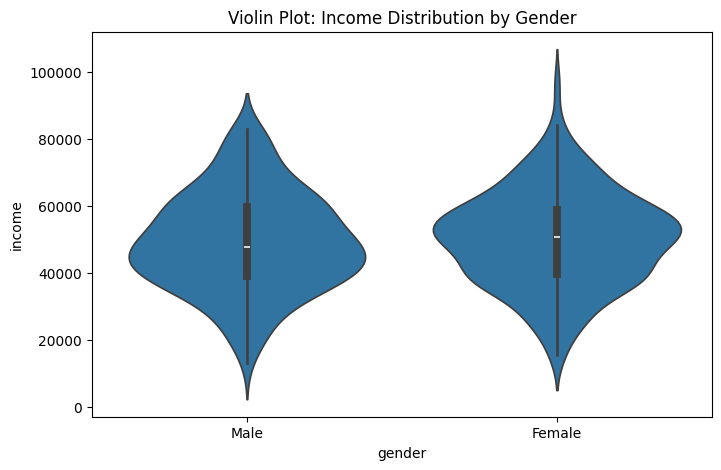

In [138]:
# Violin Plot: income distribution by gender
plt.figure(figsize=(8,5))
sns.violinplot(x='gender', y='income', data=df_plots)
plt.title('Violin Plot: Income Distribution by Gender')
plt.show();

---
### └─ **📍 Strip Plot**

**🎯 Purpose**

- Display individual data points of a numeric variable across different categories.
- Show the distribution and density of data points with minimal overlap.
- Useful for visualizing raw data and spotting clusters or outliers.

| **✅ When to Use**                                              | **❌ When Not to Use**                                                              |
| -------------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| To visualize individual observations within categories.        | When dataset is very large, causing excessive overlap (use swarm or violin plots). |
| When you want to see exact data points and their distribution. | When you need summary statistics rather than raw data (use boxplots or bar plots). |
| To detect outliers and clusters visually.                      | When categories have many data points causing clutter.                             |
| When comparing numeric values across categorical groups.       | When clearer density representation is preferred (use violin or KDE plots).        |


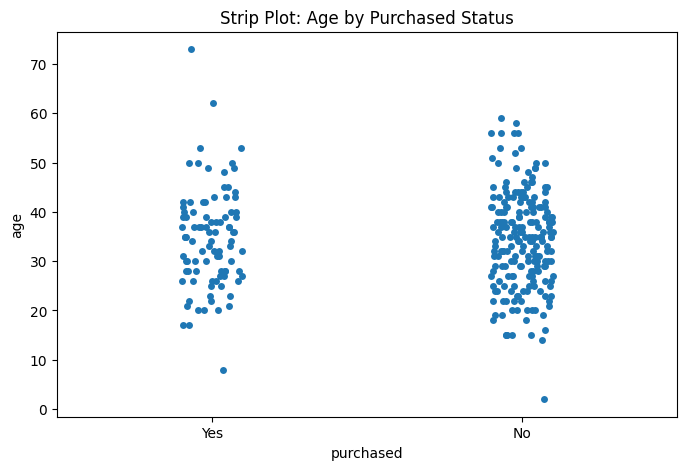

In [139]:
# Strip Plot: age points by purchased status
plt.figure(figsize=(8,5))
sns.stripplot(x='purchased', y='age', data=df_plots, jitter=True)
plt.title('Strip Plot: Age by Purchased Status')
plt.show();

---
### └─ **🐝 Swarm Plot**

**🎯 Purpose**

- Display individual data points of a numeric variable across categories without overlapping points.
- Show the distribution, density, and clustering of data with better clarity than strip plots.
- Useful for visualizing raw data and identifying outliers.

| **✅ When to Use**                                               | **❌ When Not to Use**                                                         |
| --------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| To visualize individual observations clearly within categories. | When dataset is very large, causing overplotting and clutter.                 |
| When you want to see exact data points and their distribution.  | When you need summary statistics instead of raw data (use boxplots).          |
| To detect outliers, clusters, and data patterns.                | When quick, simple summaries are preferred (use bar or box plots).            |
| When comparing numeric values across categorical groups.        | When plotting many categories with large sample sizes (may become cluttered). |


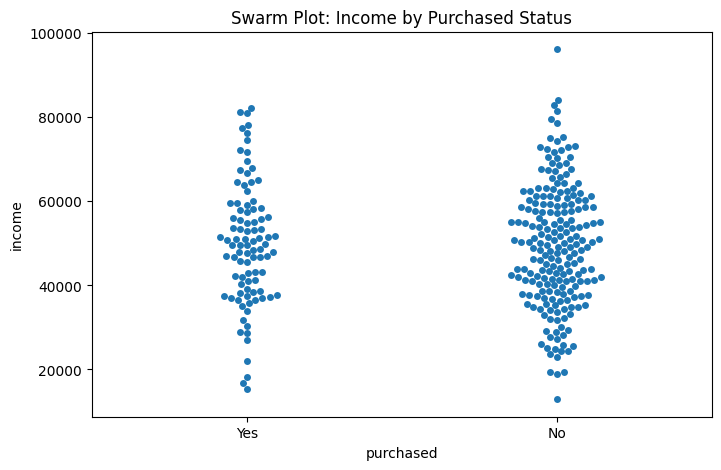

In [140]:
# Swarm Plot: income points by purchased status
plt.figure(figsize=(8,5))
sns.swarmplot(x='purchased', y='income', data=df_plots)
plt.title('Swarm Plot: Income by Purchased Status')
plt.show();

---
### └─ **📊 Bar Plot (Bivariate)**

**🎯 Purpose**

- Compare summary statistics (e.g., counts, means) of a numeric variable across two categorical variables.
- Visualize group-wise differences and interactions between categories.
- Useful for side-by-side comparison of subgroups.

| **✅ When to Use**                                                       | **❌ When Not to Use**                                                      |
| ----------------------------------------------------------------------- | -------------------------------------------------------------------------- |
| To compare aggregated numeric values across combinations of categories. | When data is continuous without grouping (use scatter or line plots).      |
| When examining interactions between two categorical variables.          | For detailed distribution shapes within groups (use box or violin plots).  |
| To visualize counts or means split by two categorical factors.          | When individual data points need to be seen (use swarm or strip plots).    |
| When highlighting differences between subgroups.                        | When categories are too numerous, making plots cluttered and hard to read. |


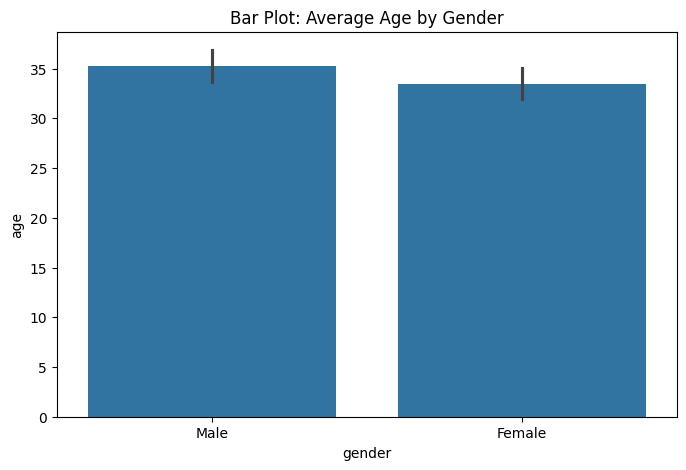

In [141]:
# Bar Plot: average age by gender
plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='age', data=df_plots)
plt.title('Bar Plot: Average Age by Gender')
plt.show();

---
---
## **🔎 B2.5. Bivariate Plots (CC)**

---
### └─ **📊 Grouped Bar Chart**

**🎯 Purpose**

- Compare counts or summary statistics of a numeric variable across categories split by a second categorical variable.
- Display side-by-side bars to easily compare subgroups within main categories.
- Useful for visualizing relationships and differences between multiple categorical factors.

| **✅ When to Use**                                                 | **❌ When Not to Use**                                                                         |
| ----------------------------------------------------------------- | --------------------------------------------------------------------------------------------- |
| To compare subgroup values clearly within each main category.     | When there are too many categories or subgroups causing clutter.                              |
| When analyzing the interaction between two categorical variables. | For detailed distributional analysis within groups (use box or violin plots).                 |
| To visualize counts, means, or sums by groups side-by-side.       | When individual data points or precise distributions are required (use swarm or strip plots). |
| When you want a clear, straightforward comparison of subgroups.   | When categories are unordered or non-categorical (use line or scatter plots).                 |


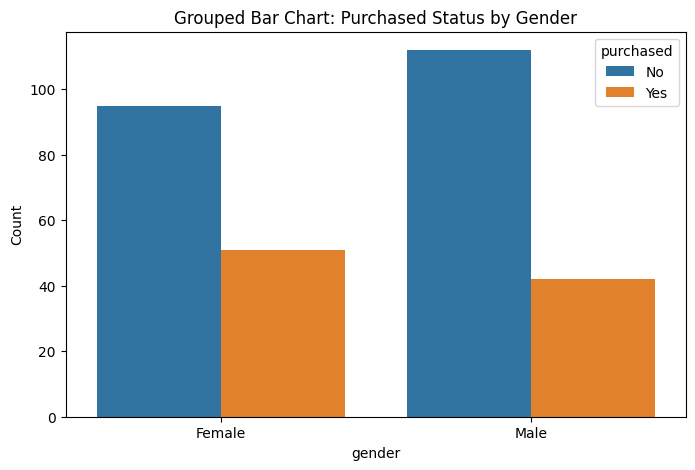

In [151]:
# Count data for grouped bar chart: count of purchased by gender
grouped_data = df_plots.groupby(['gender', 'purchased']).size().reset_index(name='count')

plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='count', hue='purchased', data=grouped_data)
plt.title('Grouped Bar Chart: Purchased Status by Gender')
plt.ylabel('Count')
plt.show();

---
### └─ **📊 Stacked Bar Chart**

**🎯 Purpose**

- Compare counts or summary statistics of a numeric variable across categories split by a second categorical variable.
- Display side-by-side bars to easily compare subgroups within main categories.
- Useful for visualizing relationships and differences between multiple categorical factors.

| **✅ When to Use**                                                 | **❌ When Not to Use**                                                                         |
| ----------------------------------------------------------------- | --------------------------------------------------------------------------------------------- |
| To compare subgroup values clearly within each main category.     | When there are too many categories or subgroups causing clutter.                              |
| When analyzing the interaction between two categorical variables. | For detailed distributional analysis within groups (use box or violin plots).                 |
| To visualize counts, means, or sums by groups side-by-side.       | When individual data points or precise distributions are required (use swarm or strip plots). |
| When you want a clear, straightforward comparison of subgroups.   | When categories are unordered or non-categorical (use line or scatter plots).                 |


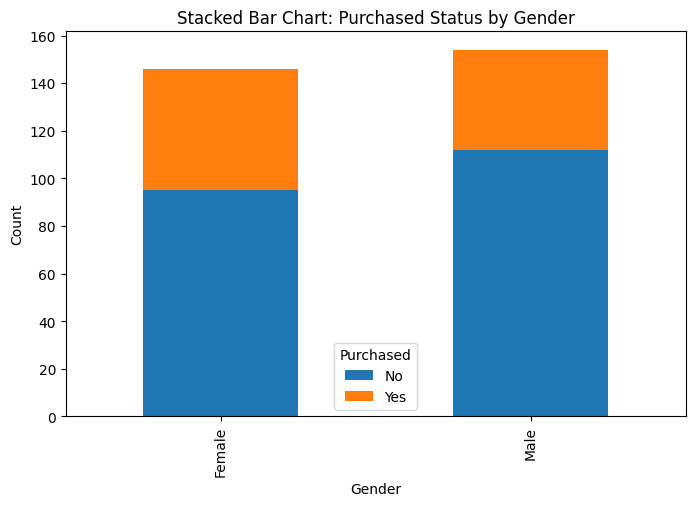

In [143]:
# Prepare data pivoted for stacking
stacked_data = df_plots.groupby(['gender', 'purchased']).size().unstack(fill_value=0)

# Plot stacked bar chart
stacked_data.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Stacked Bar Chart: Purchased Status by Gender')
plt.ylabel('Count')
plt.xlabel('Gender')
plt.legend(title='Purchased')
plt.show();

---
### └─ **🌡️ Heatmap**

**🎯 Purpose**

- Visualize data values (often numeric) across two dimensions using color intensity.
- Reveal patterns, correlations, and anomalies in matrices or cross-tabulated data.
- Commonly used for correlation matrices, pivot tables, or any grid-like data.

| **✅ When to Use**                                                                | **❌ When Not to Use**                                               |
| -------------------------------------------------------------------------------- | ------------------------------------------------------------------- |
| To show relationships or interactions between two categorical/numeric variables. | When analyzing individual data points instead of aggregated values. |
| For visualizing correlation matrices or frequency tables.                        | When the data isn't naturally in a matrix or grid format.           |
| To detect patterns, clusters, or outliers via color contrast.                    | When exact values are needed without relying on color scales.       |
| When comparing many combinations of two variables simultaneously.                | When there are too many categories, making the heatmap unreadable.  |


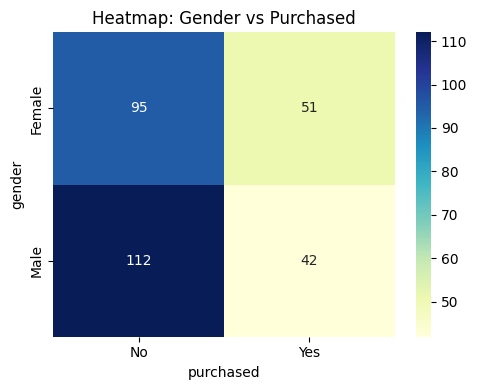

In [123]:
plt.figure(figsize=(5,4))
ct = pd.crosstab(df['gender'], df['purchased'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Heatmap: Gender vs Purchased")
plt.tight_layout()
plt.show();

---
---
## **🔎 B2.6. Multivariate Plots**

---
### └─ **🔗 Pairplot**

**🎯 Purpose**

- Visualize pairwise relationships between multiple numeric variables in a dataset.
- Provide a quick overview of potential correlations, clusters, and patterns.
- Show scatter plots for variable pairs and histograms or KDEs for individual distributions.

| **✅ When to Use**                                                     | **❌ When Not to Use**                                                                |
| --------------------------------------------------------------------- | ------------------------------------------------------------------------------------ |
| To explore relationships between several numeric variables at once.   | When there are too many variables, leading to cluttered visuals.                     |
| When identifying correlations, trends, or group separation.           | For categorical-only datasets (not useful without numeric variables).                |
| To detect patterns, clusters, or outliers across multiple dimensions. | When dealing with large datasets (plots can become slow or unreadable).              |
| When doing initial exploratory data analysis (EDA).                   | When a focused, detailed plot of just one relationship is needed (use scatter plot). |


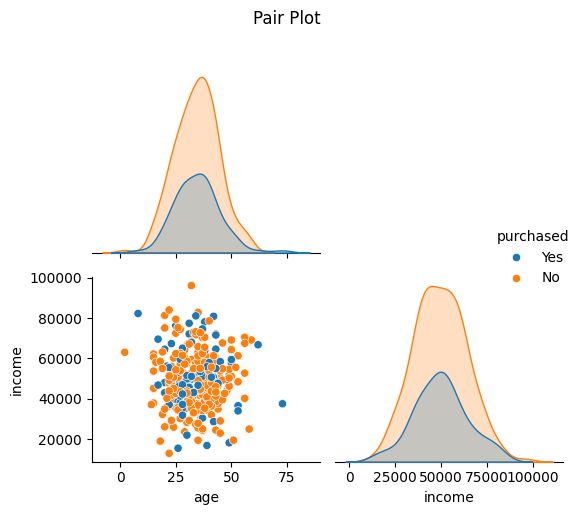

In [124]:
sns.pairplot(df, hue='purchased', diag_kind='kde', corner=True)
plt.suptitle("Pair Plot", y=1.02)
plt.tight_layout()
plt.show();

---
### └─ **🔶 Correlation Heatmap**

**🎯 Purpose**

- Visualize the strength and direction of linear relationships between numeric variables.
- Help identify multicollinearity, redundant features, or strong predictors.
- Use color gradients to show correlation coefficients (ranging from -1 to 1).

| **✅ When to Use**                                                     | **❌ When Not to Use**                                                                                       |
| --------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------- |
| To detect strong positive or negative correlations between variables. | When variables are mostly categorical (correlation isn't meaningful).                                       |
| When checking for multicollinearity before modeling.                  | When the goal is to understand complex, nonlinear relationships (use scatter plots or advanced techniques). |
| To simplify feature selection or dimensionality reduction.            | When working with very few variables (simple pairwise plots may be better).                                 |
| When you want a quick overview of relationships in numeric data.      | When interpreting correlation strength without statistical significance (can be misleading).                |


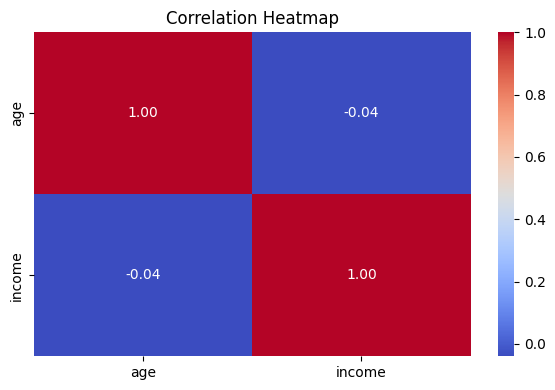

In [125]:
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show();

---
### └─ **🧊 3D Scatterplot**

**🎯 Purpose**

- Visualize relationships among three continuous numeric variables in three-dimensional space.
- Help detect trends, clusters, or outliers that may not be visible in 2D plots.
- Useful for high-dimensional exploratory data analysis.

| **✅ When to Use**                                                           | **❌ When Not to Use**                                                               |
| --------------------------------------------------------------------------- | ----------------------------------------------------------------------------------- |
| To explore relationships among three numeric variables simultaneously.      | When two variables are sufficient to explain the pattern (2D scatter is clearer).   |
| When visualizing clusters, group separation, or spatial distributions.      | When interpretability is key — 3D plots can be hard to read on static images.       |
| For high-dimensional data with meaningful third variable.                   | For categorical data or when variables lack continuous scale.                       |
| When an interactive environment (e.g., Plotly, Matplotlib 3D) is available. | When working with print or non-interactive media — may be hard to extract insights. |


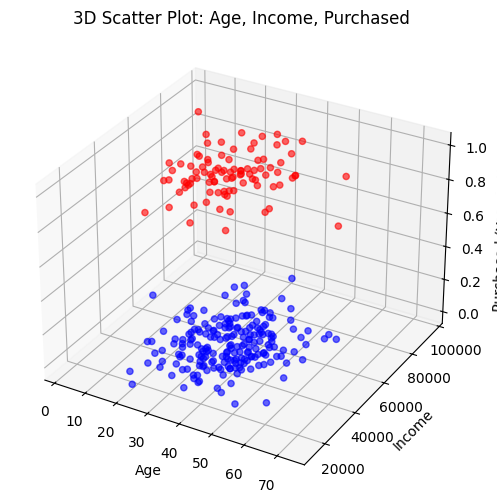

In [144]:
# --- 3D Scatter Plot ---
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Scatter by age, income, and random values for size, colored by purchased
scatter = ax.scatter(
    df_plots['age'], 
    df_plots['income'], 
    df_plots['purchased'].map({'Yes': 1, 'No': 0}),  # encode purchased as numeric for z-axis
    c=df_plots['purchased'].map({'Yes': 'red', 'No': 'blue'}),
    alpha=0.6
)

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Purchased (Yes=1, No=0)')
plt.title('3D Scatter Plot: Age, Income, Purchased')
plt.show();

---
### └─ **🫧 Bubble Plot**

**🎯 Purpose**

- Extend scatter plots by using point size to represent a third continuous variable.
- Visualize relationships between two numeric variables and the relative magnitude of a third.
- Useful for showing patterns, clusters, and size-based comparisons in one plot.

| **✅ When to Use**                                                                 | **❌ When Not to Use**                                                   |
| --------------------------------------------------------------------------------- | ----------------------------------------------------------------------- |
| To show relationships between two numeric variables and compare a third via size. | When bubble sizes distort perception or are hard to interpret.          |
| When visualizing economic, geographic, or resource-related metrics.               | When exact values of the third variable are needed (use labeled plots). |
| To detect patterns, outliers, or size-based groupings.                            | When visual clarity is lost due to overlapping or very large bubbles.   |
| For intuitive comparisons of magnitude in a multivariable context.                | When dealing with categorical variables or small datasets.              |


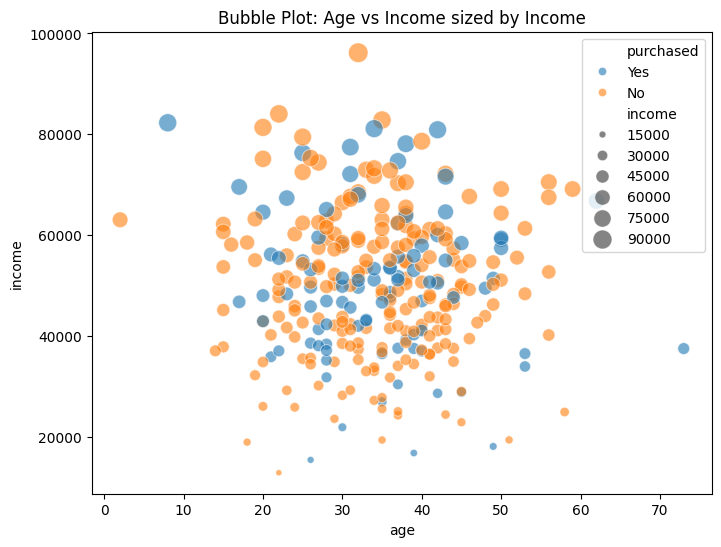

In [145]:
# --- Bubble Plot ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_plots,
    x='age', y='income',
    size='income',  # bubble size proportional to income
    hue='purchased',
    alpha=0.6,
    sizes=(20, 200)  # min and max bubble sizes
)
plt.title('Bubble Plot: Age vs Income sized by Income')
plt.show();

---
### └─ **🗂️ Facet Grid**

**🎯 Purpose**

- Create a grid of subplots based on the values of one or more categorical variables.
- Allow visual comparison of distributions or relationships across different subsets of the data.
- Useful for multi-panel exploratory data analysis with clear separation by groups.

| **✅ When to Use**                                                | **❌ When Not to Use**                                                                         |
| ---------------------------------------------------------------- | --------------------------------------------------------------------------------------------- |
| To compare patterns across multiple categories or subgroups.     | When the number of unique categories is too high (grid becomes cluttered).                    |
| When exploring how distributions or relationships vary by group. | When you need to visualize many continuous variables (better to use pair plots).              |
| To maintain consistent axes and scales across subplots.          | When each plot needs a unique scale (FacetGrid uses shared axes by default).                  |
| When presenting clean, organized multi-panel comparisons.        | When screen space is limited or when interactivity is needed (consider Plotly or dashboards). |


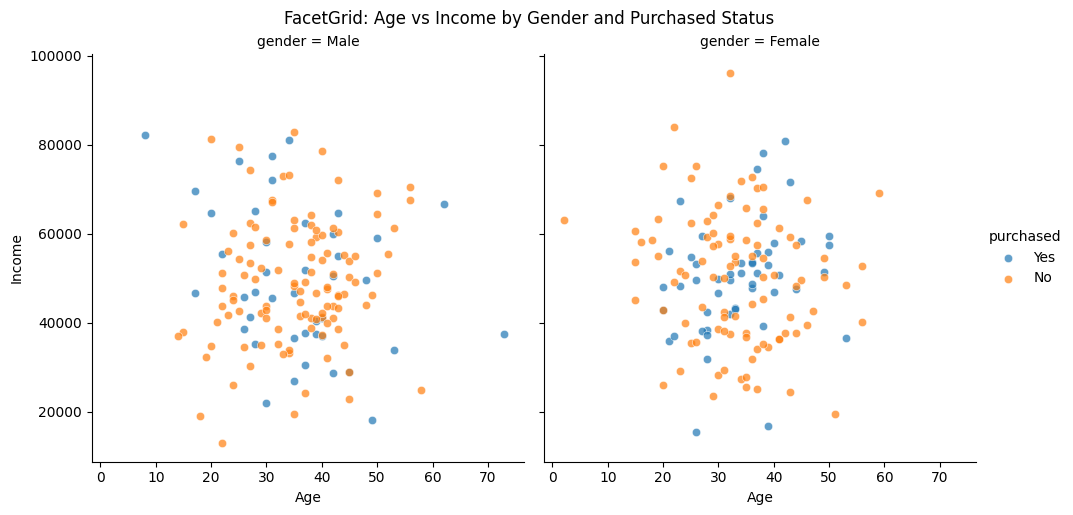

In [146]:
# --- FacetGrid ---
g = sns.FacetGrid(df_plots, col='gender', hue='purchased', height=5, aspect=1)
g.map(sns.scatterplot, 'age', 'income', alpha=0.7)
g.add_legend()
g.set_axis_labels('Age', 'Income')
g.fig.suptitle('FacetGrid: Age vs Income by Gender and Purchased Status', y=1.02)
plt.show();

---
---
---
# **🧼 B3. Data Cleaning**

In [25]:
df_cleaned = df.copy()

---
---
## **🧼 B3.1. Common functions**

---
### └─ **🧼 Apply snake case to column names**

In [26]:
import re
def convert_column_names_to_snake_case(df):
    print("   └── Converting column names to snake_case...")
    def to_snake_case(text):
        text = text.lower().strip()
        text = re.sub(r'\s+', '_', text)            
        text = re.sub(r'[^a-z0-9_]', '', text)      
        return text
    
    df = df.copy()
    df.columns = [to_snake_case(col) for col in df.columns]
    return df

In [27]:
df_sample = pd.DataFrame({
    'First Name': ['Alice', 'Bob', 'Charlie'],
    'Last Name': ['Smith', 'Jones', 'Brown'],
    'Favorite Color': ['Blue', 'Green', 'Red'],
    'Year of Birth': [1990, 1985, 1978]
})

df_sample = convert_column_names_to_snake_case(df_sample)
df_sample.head()

   └── Converting column names to snake_case...


,first_name,last_name,favorite_color,year_of_birth
0,Alice,Smith,Blue,1990
1,Bob,Jones,Green,1985
2,Charlie,Brown,Red,1978


---
### └─ **🧼 Drop duplicates**

In [28]:
def drop_duplicates(df, subset=None):
    if subset:
        print(f"   └── Dropping duplicates based on subset columns: {subset}")
    else:
        print("   └── Dropping duplicates based on all columns...")
    df = df.copy()
    df = df.drop_duplicates(subset=subset)
    return df

In [29]:
df_sample = pd.DataFrame({
    'id': [1, 2, 2, 3, 4, 4, 5],
    'name': ['Alice', 'Bob', 'Bob', 'Charlie', 'David', 'David', 'Eve'],
    'age': [25, 30, 30, 35, 40, 40, 45]
})

df_sample = drop_duplicates(df_sample, subset=['id', 'name'])
df_sample

   └── Dropping duplicates based on subset columns: ['id', 'name']


,id,name,age
0,1,Alice,25
1,2,Bob,30
3,3,Charlie,35
4,4,David,40
6,5,Eve,45


---
### └─ **🧼 Mark missing values**

In [30]:
def mark_missing_numerical(df, placeholder_value=999, columns=[]):
    print(f"   └── Imputing missing values in numerical columns: {columns} with placeholder: {placeholder_value}")
    df = df.copy()
    for column in columns:
        if column in df.columns and df[column].isnull().any():
            df[column] = df[column].fillna(placeholder_value)
    return df

In [31]:
def mark_missing_categorical(df, placeholder_value='missing', columns=[]):
    print(f"   └── Imputing missing values in categorical columns: {columns} with placeholder: '{placeholder_value}'")
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = df[col].astype('object')  # ensure consistent dtype
            df[col] = df[col].fillna(placeholder_value)
    return df

In [32]:
df_sample = pd.DataFrame({
    'age': [25, 30, np.nan, 40, np.nan],
    'income': [50000, 60000, 55000, np.nan, 100000],
    'score': [1, np.nan, 3, 4, 5],
    'gender': ['Male', 'Female', None, 'Male', 'Female'],
    'city': ['New York', np.nan, 'Los Angeles', 'Chicago', None]
})

df_sample = mark_missing_numerical(df_sample, placeholder_value=999, columns=['age'])
df_sample = mark_missing_categorical(df_sample, placeholder_value="missing", columns=['gender'])
df_sample

   └── Imputing missing values in numerical columns: ['age'] with placeholder: 999
   └── Imputing missing values in categorical columns: ['gender'] with placeholder: 'missing'


,age,income,score,gender,city
0,25.0,50000.0,1.0,Male,New York
1,30.0,60000.0,NaN,Female,NaN
2,999.0,55000.0,3.0,missing,Los Angeles
3,40.0,NaN,4.0,Male,Chicago
4,999.0,100000.0,5.0,Female,None


---
### └─ **🧼 Map values**

In [33]:
def map_values(df, mapping_dict):
    print(f"   └── Mapping values for columns: {list(mapping_dict.keys())}")
    df = df.copy()
    columns = mapping_dict.keys()
    for col in columns:
        if col in df.columns and col in mapping_dict:
            df[col] = df[col].map(mapping_dict[col]).fillna(df[col])
    return df

In [34]:
df_sample = pd.DataFrame({
    'Subscription Status': ['yes', 'no', 'no', 'yes'],
    'Gender': ['Male', 'Female', 'Female', 'Male'],
    'Age': [25, 30, 22, 40]
})

mapping = {
    'Subscription Status': {'yes': 1, 'no': 0},
    # 'Gender': {'Male': 0, 'Female': 1}
}

df_sample = map_values(df_sample, mapping)
df_sample

   └── Mapping values for columns: ['Subscription Status']


,Subscription Status,Gender,Age
0,1,Male,25
1,0,Female,30
2,0,Female,22
3,1,Male,40


---
### └─ **🧼 Convert text to lowercase**

In [35]:
def convert_text_to_lowercase(df, columns=[]):
    print(f"   └── Converting text to lowercase for columns: {columns}")
    df = df.copy()
    for col in columns:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].str.lower()
    return df

In [36]:
df_sample = pd.DataFrame({
    'Name': ['Alice', 'BOB', 'Charlie'],
    'City': ['New York', 'LONDON', 'ToKyo'],
    'Age': [25, 30, 22]
})

df_sample = convert_text_to_lowercase(df_sample, columns=['Name'])
df_sample

   └── Converting text to lowercase for columns: ['Name']


,Name,City,Age
0,alice,New York,25
1,bob,LONDON,30
2,charlie,ToKyo,22


---
### └─ **🧼 Replace character**

In [37]:
def replace_character_in_columns(df, to_replace, replacement, columns=[]):
    print(f"   └── Replacing '{to_replace}' with '{replacement}' in columns: {columns}")
    df = df.copy()
    for col in columns:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].str.replace(to_replace, replacement, regex=False)
    return df

In [38]:
df_sample = pd.DataFrame({
    'name': ['Alice Smith', 'Bob.Jones', 'Charlie.Lane'],
    'city': ['New York', 'Los_Angeles', 'San_Francisco']
})

df_sample = replace_character_in_columns(df_sample, to_replace='.', replacement=' ', columns=['name'])
df_sample

   └── Replacing '.' with ' ' in columns: ['name']


,name,city
0,Alice Smith,New York
1,Bob Jones,Los_Angeles
2,Charlie Lane,San_Francisco


---
### └─ **🧼 Get absolute values**

In [39]:
def get_absolute_values(df, columns=[]):
    print(f"   └── Taking absolute values for columns: {columns}")
    df = df.copy()
    for col in columns:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].abs()
    return df

In [40]:
df_sample = pd.DataFrame({
    'age': [25, -30, 45, -50, 60],
    'income': [-50000, 60000, -55000, 70000, -100000],
    'score': [1, -2, 3, -4, 5],
    'gender': ['Male', 'Female', 'Female', 'Male', 'Male']  # non-numeric column remains unchanged
})

df_sample = get_absolute_values(df_sample, columns=['age', 'score'])
df_sample

   └── Taking absolute values for columns: ['age', 'score']


,age,income,score,gender
0,25,-50000,1,Male
1,30,60000,2,Female
2,45,-55000,3,Female
3,50,70000,4,Male
4,60,-100000,5,Male


---
### └─ **🧼 Convert data type**

In [41]:
def convert_columns_dtype(df, columns_types):
    df = df.copy()
    for col, dtype in columns_types.items():
        if col in df.columns:
            print(f"   └── Converting column '{col}' to '{dtype}'")
            if dtype == 'numeric':
                df[col] = pd.to_numeric(df[col], errors='coerce')
            elif dtype == 'category':
                df[col] = df[col].astype('category')
            elif dtype == 'string':
                df[col] = df[col].astype('string')
            elif dtype == 'datetime':
                df[col] = pd.to_datetime(df[col], errors='coerce')
            else:
                # For other types like 'int', 'float', etc.
                try:
                    df[col] = df[col].astype(dtype)
                except Exception as e:
                    print(f"      ! Warning: Could not convert column '{col}' to '{dtype}': {e}")
    return df

In [42]:
df_sample = pd.DataFrame({
    'age': ['25', '30', '35', '40', 'not available'],
    'gender': ['Male', 'Female', 'Female', 'Male', 'Female'],
    'signup_date': ['2023-01-10', '2023-02-15', '2023-03-20', 'not a date', '2023-05-01'],
    'score': ['88.5', '92.3', '85.0', '90.2', '87.7'],
    'user_id': [101, 102, 103, 104, 105]
})

df_sample = convert_columns_dtype(df_sample, {
    'age': 'numeric',
    'gender': 'category',
    'signup_date': 'datetime',
    # 'score': 'float',
    # 'user_id': 'string'
})
df_sample.dtypes

   └── Converting column 'age' to 'numeric'
   └── Converting column 'gender' to 'category'
   └── Converting column 'signup_date' to 'datetime'


age                   float64
gender               category
signup_date    datetime64[ns]
score                  object
user_id                 int64
dtype: object

---
---
## **🧼 B3.2. Custom functions**

In [43]:
def convert_target_to_binary(df):
    df = df.copy()
    df['Subscription Status'] = df['Subscription Status'].map({'no': 0, 'yes': 1}).fillna(df['Subscription Status'])
    return df

---
---
## **🧼 B3.3. Apply pipeline**

In [44]:
cleaning_funcs = [
    lambda df: convert_column_names_to_snake_case(df),
    # lambda df: drop_duplicates(df, subset=['target']),
    # lambda df: get_absolute_values(df, columns=['longitude']),
    # lambda df: convert_target_to_binary(df),
    # Add more custom cleaning steps here
]

In [45]:
for func in cleaning_funcs:
    df_cleaned = func(df_cleaned)

   └── Converting column names to snake_case...


In [46]:
print("DataFrame Shape:", df_cleaned.shape)
df_cleaned.head()

DataFrame Shape: (569, 31)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
---
---
# **✂️ B4. Data Splitting**

In [47]:
from sklearn.model_selection import train_test_split

---
**✂️ Define the target and features**

In [48]:
X = df_cleaned.drop(columns=[TARGET])
y = df_cleaned[TARGET]

---
**✂️ Split data (stratify if classification)**

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y if y.nunique() <= 20 else None
)

print(f"Original Shape: {df_cleaned.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Original Shape: (569, 31)
X_train shape: (455, 30)
y_train shape: (455,)
X_test shape: (114, 30)
y_test shape: (114,)


---
**✂️ Show distribution in Train and Test sets**

In [50]:
# Calculate normalized value counts
train_dist = y_train.value_counts(normalize=True).rename("Train")
test_dist = y_test.value_counts(normalize=True).rename("Test")

# Combine into a DataFrame
dist_df = pd.concat([train_dist, test_dist], axis=1).fillna(0)

# Convert to percentage format
dist_df = (dist_df * 100).round(2).astype(str) + '%'

# Display
dist_df

,Train,Test
target,,
1,62.64%,63.16%
0,37.36%,36.84%


---
---
---
# **🛠️ B5. Feature Engineering**

In [51]:
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)
print(f'Train Set Shape: {df_train.shape}')
print(f'Test Set Shape: {df_test.shape}')

Train Set Shape: (455, 31)
Test Set Shape: (114, 31)


---
---
## **🛠️ B5.1. General**

---
### └─ **🛠️ Drop columns**

In [52]:
def drop_columns(
    df_train,
    df_test,
    columns_to_drop   # list of column names to drop
):
    print(f"   └── Dropping columns: {columns_to_drop}")

    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()

    for col in columns_to_drop:
        if col not in df_train_copy.columns and col not in df_test_copy.columns:
            print(f"      ! Warning: Column '{col}' not found in both train and test DataFrames, skipping")
            continue
        if col in df_train_copy.columns:
            df_train_copy.drop(columns=col, inplace=True)
        if col in df_test_copy.columns:
            df_test_copy.drop(columns=col, inplace=True)

    return df_train_copy, df_test_copy

In [53]:
df_sample_train = pd.DataFrame({
    'age': [25, 30, 22, 45],
    'gender': ['M', 'F', 'F', 'M'],
    'income': [50000, 60000, 52000, 58000],
    'unnecessary_col1': ['x', 'y', 'z', 'w'],
    'unnecessary_col2': [1, 2, 3, 4]
})

df_sample_test = pd.DataFrame({
    'age': [35, 40, 28],
    'gender': ['F', 'M', 'F'],
    'income': [62000, 61000, 59000],
    'unnecessary_col1': ['a', 'b', 'c'],
    'unnecessary_col2': [5, 6, 7]
})

df_sample_train, df_sample_test = drop_columns(
    df_sample_train,
    df_sample_test,
    columns_to_drop=['unnecessary_col1', 'unnecessary_col2']
)

print(f"\nCleaned Train DataFrame:")
df_sample_train
print(f"\nCleaned Test DataFrame:")
df_sample_test

   └── Dropping columns: ['unnecessary_col1', 'unnecessary_col2']

Cleaned Train DataFrame:


,age,gender,income
0,25,M,50000
1,30,F,60000
2,22,F,52000
3,45,M,58000



Cleaned Test DataFrame:


,age,gender,income
0,35,F,62000
1,40,M,61000
2,28,F,59000


---
---
## **🛠️ B5.2. Missing values**

---
### └─ **🛠️ Remove rows**

In [54]:
def remove_rows_with_placeholder(
    df_train,
    df_test,
    columns,
    placeholder='unknown'
):
    print(f"   └── Removing rows with value '{placeholder}' in columns: {columns}...")

    if df_train is None or df_test is None:
        raise ValueError("Both df_train and df_test must be provided.")

    total_rows_before = len(df_train) + len(df_test)
    total_rows_removed = 0

    def filter_df(df, name):
        df_filtered = df.copy()
        for col in columns:
            if col in df_filtered.columns:
                df_filtered = df_filtered[df_filtered[col] != placeholder]
        removed = len(df) - len(df_filtered)
        print(f"       └── {name}: Removed {removed} rows")
        return df_filtered, removed

    df_train_cleaned, removed_train = filter_df(df_train, "Train")
    df_test_cleaned, removed_test = filter_df(df_test, "Test")

    total_rows_removed = removed_train + removed_test
    total_rows_after = total_rows_before - total_rows_removed
    percentage_remaining = (total_rows_after / total_rows_before) * 100 if total_rows_before > 0 else 0

    print(f"       └── Total rows removed: {total_rows_removed} "
          f"({(total_rows_removed / total_rows_before) * 100:.4f}% of the dataset)")
    print(f"       └── {percentage_remaining:.4f}% of the dataset remains after removal")

    return df_train_cleaned, df_test_cleaned

In [55]:
df_sample_train = pd.DataFrame({
    'name': ['Alice', 'Bob', 'unknown', 'David'],
    'city': ['New York', 'unknown', 'Los Angeles', 'Chicago'],
    'age': [25, 30, 35, 40]
})
df_sample_test = pd.DataFrame({
    'name': ['Eve', 'Frank', 'Grace', 'unknown'],
    'city': ['Houston', 'Phoenix', 'Los Angeles', 'Seattle'],
    'age': [28, 33, 29, 41]
})

df_sample_train, df_sample_test = remove_rows_with_placeholder(
    df_sample_train, 
    df_sample_test,
    columns=['name', 'city'],
    placeholder='unknown'
)
print(f"\nCleaned Train DataFrame:")
df_sample_train
print(f"\nCleaned Test DataFrame:")
df_sample_test

   └── Removing rows with value 'unknown' in columns: ['name', 'city']...
       └── Train: Removed 2 rows
       └── Test: Removed 1 rows
       └── Total rows removed: 3 (37.5000% of the dataset)
       └── 62.5000% of the dataset remains after removal

Cleaned Train DataFrame:


,name,city,age
0,Alice,New York,25
3,David,Chicago,40



Cleaned Test DataFrame:


,name,city,age
0,Eve,Houston,28
1,Frank,Phoenix,33
2,Grace,Los Angeles,29


---
### └─ **🛠️ Impute with aggregate**

In [56]:
def impute_marked_missing_values(
    df_train,
    df_test,
    columns,
    placeholder='unknown',      # You can change this to '999' or 'N/A' and run again
    strategy='mean',            # Try 'mean', 'median', 'mode', or 'constant'
    constant_fill_value=None    # Only needed if strategy is 'constant'
):
    print(f"   └── Replacing placeholder '{placeholder}' using strategy '{strategy}' for columns: {columns}")

    df_train_imputed = df_train.copy()
    df_test_imputed = df_test.copy()

    for col in columns:
        if col not in df_train.columns:
            print(f"       └── Column '{col}' not found in train set. Skipping...")
            continue

        print(f"       └── Imputing column: '{col}'")

        # Replace placeholder temporarily with NaN to allow imputation
        df_train_temp = df_train_imputed[col].replace(placeholder, pd.NA)
        df_test_temp = df_test_imputed[col].replace(placeholder, pd.NA)

        # Determine fill value from train only
        if strategy == 'mean':
            fill_value = pd.to_numeric(df_train_temp, errors='coerce').mean()
        elif strategy == 'median':
            fill_value = pd.to_numeric(df_train_temp, errors='coerce').median()
        elif strategy == 'mode':
            mode_series = df_train_temp.mode()
            fill_value = mode_series.iloc[0] if not mode_series.empty else placeholder
        elif strategy == 'constant':
            fill_value = constant_fill_value
        else:
            raise ValueError(f"Unsupported strategy '{strategy}'")

        # Impute placeholder values
        df_train_imputed[col] = df_train_imputed[col].replace(placeholder, fill_value)
        df_test_imputed[col] = df_test_imputed[col].replace(placeholder, fill_value)

        print(f"           └── Replaced placeholder with: {fill_value}")

    return df_train_imputed, df_test_imputed

In [57]:
df_sample_train = pd.DataFrame({
    'age': ['25', '30', 'unknown', '45', '999'],
    'income': ['50000', '60000', '70000', 'N/A', '55000'],
    'gender': ['male', 'female', 'unknown', 'female', 'male']
})

df_sample_test = pd.DataFrame({
    'age': ['35', 'unknown', '40', '999', '50'],
    'income': ['65000', 'N/A', '62000', '71000', 'unknown'],
    'gender': ['unknown', 'female', 'male', 'unknown', 'female']
})

df_sample_train, df_sample_test = impute_marked_missing_values(
    df_sample_train,
    df_sample_test,
    columns=['age', 'income', 'gender'],
    placeholder='unknown',  # You can change this to '999' or 'N/A' and run again
    strategy='mean',        # Try 'mean', 'median', 'mode', or 'constant'
    # constant_fill_value=0   # Only needed if strategy is 'constant'
)
print(f"\nCleaned Train DataFrame:")
df_sample_train
print(f"\nCleaned Test DataFrame:")
df_sample_test

   └── Replacing placeholder 'unknown' using strategy 'mean' for columns: ['age', 'income', 'gender']
       └── Imputing column: 'age'
           └── Replaced placeholder with: 274.75
       └── Imputing column: 'income'
           └── Replaced placeholder with: 58750.0
       └── Imputing column: 'gender'
           └── Replaced placeholder with: nan

Cleaned Train DataFrame:


,age,income,gender
0,25,50000,male
1,30,60000,female
2,274.75,70000,NaN
3,45,N/A,female
4,999,55000,male



Cleaned Test DataFrame:


,age,income,gender
0,35,65000,NaN
1,274.75,N/A,female
2,40,62000,male
3,999,71000,NaN
4,50,58750.0,female


---
### └─ **🛠️ Impute with KNN**

- A generic imputation technique that can work on numerical data (and sometimes encoded categorical data).

- Imputes missing values based on the values of the nearest neighbors (using Euclidean or other distance metrics).

- Good for numerical data, but less straightforward or accurate for categorical data unless categories are encoded carefully.

In [58]:
from sklearn.impute import KNNImputer
import pandas as pd
import numpy as np

def impute_with_knn(
    df_train,
    df_test,
    columns_for_knn,          # Numeric columns used for computing distance (all must be numeric)
    column_to_impute,         # Single column name to impute
    placeholder='unknown',    # Placeholder value representing missing in the target column
    n_neighbors=5
):
    print(f"   └── KNN Imputation (n={n_neighbors}) for target column: {column_to_impute}")
    print(f"       └── Using these numeric features to compute similarity: {columns_for_knn}")

    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()

    # Replace placeholder only in the column to impute
    df_train_copy[column_to_impute] = pd.to_numeric(
        df_train_copy[column_to_impute].replace(placeholder, np.nan), errors='coerce'
    )
    df_test_copy[column_to_impute] = pd.to_numeric(
        df_test_copy[column_to_impute].replace(placeholder, np.nan), errors='coerce'
    )

    # Ensure all columns_for_knn are numeric
    train_knn_input = df_train_copy[columns_for_knn].apply(pd.to_numeric, errors='coerce')
    test_knn_input = df_test_copy[columns_for_knn].apply(pd.to_numeric, errors='coerce')

    # Fit KNN imputer
    imputer = KNNImputer(n_neighbors=n_neighbors)
    train_imputed_array = imputer.fit_transform(train_knn_input)
    test_imputed_array = imputer.transform(test_knn_input)

    # Get the dtype of the original column
    original_dtype = df_train[column_to_impute].dtype

    # Extract imputed values into DataFrames
    train_imputed_df = pd.DataFrame(train_imputed_array, columns=columns_for_knn, index=df_train_copy.index)
    test_imputed_df = pd.DataFrame(test_imputed_array, columns=columns_for_knn, index=df_test_copy.index)

    # Replace only the missing values in target column with imputed values, cast safely
    df_train_copy[column_to_impute] = np.where(
        df_train_copy[column_to_impute].isna(),
        train_imputed_df[column_to_impute],
        df_train_copy[column_to_impute]
    ).astype(original_dtype)

    df_test_copy[column_to_impute] = np.where(
        df_test_copy[column_to_impute].isna(),
        test_imputed_df[column_to_impute],
        df_test_copy[column_to_impute]
    ).astype(original_dtype)

    return df_train_copy, df_test_copy

In [59]:
# Sample training DataFrame
df_sample_train = pd.DataFrame({
    'age': [25, 30, -999, 45, 60],
    'income': [50000, 60000, 70000, 55000, 55000],
    'score': [80, 85, 90, 45, 75],
    'gender': ['male', 'female', 'female', 'unknown', 'male']
})

# Sample testing DataFrame
df_sample_test = pd.DataFrame({
    'age': [35, -999, 40, 20, 50],
    'income': [40000, 50000, 62000, 71000, 80000],
    'score': [85, 74, 88, 90, 82],
    'gender': ['female', 'female', 'male', 'unknown', 'female']
})

df_sample_train, df_sample_test = impute_with_knn(
    df_sample_train,
    df_sample_test,
    columns_for_knn=['age', 'income', 'score'],  # Must be numeric or convertible
    column_to_impute='age',
    placeholder=-999,                     # You can also run it for '999' and 'N/A'
    n_neighbors=3
)
print(f"\nCleaned Train DataFrame:")
df_sample_train
print(f"\nCleaned Test DataFrame:")
df_sample_test

   └── KNN Imputation (n=3) for target column: age
       └── Using these numeric features to compute similarity: ['age', 'income', 'score']

Cleaned Train DataFrame:


,age,income,score,gender
0,25,50000,80,male
1,30,60000,85,female
2,45,70000,90,female
3,45,55000,45,unknown
4,60,55000,75,male



Cleaned Test DataFrame:


,age,income,score,gender
0,35,40000,85,female
1,43,50000,74,female
2,40,62000,88,male
3,20,71000,90,unknown
4,50,80000,82,female


---
### └─ **🛠️ Impute with K-Modes**

- Designed specifically for categorical data clustering.

- Uses a simple matching dissimilarity measure (count of mismatches) for categorical variables.

- Best when your dataset (or clustering variables) are purely categorical.

- Can be used for imputation by assigning cluster modes to missing values.

In [60]:
import pandas as pd
import numpy as np
from kmodes.kmodes import KModes

def impute_with_kmodes(
    df_train,
    df_test,
    columns_for_clustering,    # All categorical columns used for clustering (distance)
    column_to_impute,          # Single categorical column to actually impute
    placeholder='unknown',     # Placeholder string representing missing value
    n_clusters=5,
    random_state=42
):
    print(f"   └── KModes Imputation (k={n_clusters}) for target column: {column_to_impute}")
    print(f"       └── Using these categorical features to cluster similarity: {columns_for_clustering}")

    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()

    # Replace placeholder with np.nan for clustering and imputation in clustering columns
    for col in columns_for_clustering:
        df_train_copy[col] = df_train_copy[col].replace(placeholder, np.nan)
        df_test_copy[col] = df_test_copy[col].replace(placeholder, np.nan)

    # Fit KModes on training data (only clustering columns)
    train_cluster_data = df_train_copy[columns_for_clustering].fillna('missing_placeholder').astype(str)
    km = KModes(n_clusters=n_clusters, init='Huang', n_init=5, random_state=random_state)
    cluster_labels = km.fit_predict(train_cluster_data)

    # Get cluster modes (most frequent category) for each cluster & each column
    cluster_modes = pd.DataFrame(km.cluster_centroids_, columns=columns_for_clustering)

    # Helper function to impute only the target column; others keep original values (including placeholder)
    def impute_row(row, cluster_label, original_row):
        if (pd.isna(row[column_to_impute]) or original_row[column_to_impute] == placeholder):
            row[column_to_impute] = cluster_modes.loc[cluster_label, column_to_impute]
        # Keep all other columns unchanged
        for col in columns_for_clustering:
            if col != column_to_impute:
                row[col] = original_row[col]
        return row

    # Impute train set
    df_train_copy['__cluster'] = cluster_labels
    df_train_copy = df_train_copy.apply(
        lambda row: impute_row(row, row['__cluster'], df_train.loc[row.name]),
        axis=1
    )
    df_train_copy.drop(columns='__cluster', inplace=True)

    # Assign clusters to test set by finding closest cluster mode (Hamming distance)
    def assign_cluster(row):
        row_vals = row[columns_for_clustering].fillna('missing_placeholder').astype(str).values
        distances = (cluster_modes.values != row_vals).sum(axis=1)
        return np.argmin(distances)

    df_test_copy['__cluster'] = df_test_copy.apply(assign_cluster, axis=1)
    df_test_copy = df_test_copy.apply(
        lambda row: impute_row(row, row['__cluster'], df_test.loc[row.name]),
        axis=1
    )
    df_test_copy.drop(columns='__cluster', inplace=True)

    return df_train_copy, df_test_copy

In [61]:
# Sample training data
df_sample_train = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'unknown', 'blue', 'green', 'red', 'unknown', 'green'],
    'shape': ['circle', 'square', 'triangle', 'circle', 'circle', 'triangle', 'circle', 'square', 'circle'],
    'size': ['small', 'medium', 'large', 'small', 'medium', 'large', 'small', 'medium', 'large']
})

# Sample test data
df_sample_test = pd.DataFrame({
    'color': ['blue', 'unknown', 'red', 'green', 'unknown'],
    'shape': ['triangle', 'triangle', 'square', 'square', 'circle'],
    'size': ['medium', 'large', 'small', 'large', 'medium']
})

# Call the KModes imputation function
df_sample_train, df_sample_test = impute_with_kmodes(
    df_sample_train,
    df_sample_test,
    columns_for_clustering=['color', 'shape', 'size'],
    column_to_impute='color',
    placeholder='unknown',
    n_clusters=3,
    random_state=42
)

print("\nImputed Train DataFrame:")
df_sample_train
print("\nImputed Test DataFrame:")
df_sample_test

   └── KModes Imputation (k=3) for target column: color
       └── Using these categorical features to cluster similarity: ['color', 'shape', 'size']

Imputed Train DataFrame:


,color,shape,size
0,red,circle,small
1,blue,square,medium
2,green,triangle,large
3,red,circle,small
4,blue,circle,medium
5,green,triangle,large
6,red,circle,small
7,blue,square,medium
8,green,circle,large



Imputed Test DataFrame:


,color,shape,size
0,blue,triangle,medium
1,green,triangle,large
2,red,square,small
3,green,square,large
4,blue,circle,medium


---
### └─ **🛠️ Impute with K-Prototypes**

- Extension of K-Modes that can handle mixed data types (both categorical and numerical).

- Combines Euclidean distance for numeric features + matching dissimilarity for categorical ones.

- If your dataset has both numerical and categorical features, this is often the better choice.

- Clustering with K-Prototypes better captures similarities in mixed-type datasets.

In [62]:
import pandas as pd
import numpy as np
from kmodes.kprototypes import KPrototypes

def impute_with_kprototypes(
    df_train,
    df_test,
    columns_for_clustering,       # All columns used for clustering (categorical + numeric)
    column_to_impute,             # The single column to impute
    cat_placeholder='unknown',    # Placeholder for missing categorical values
    num_placeholder=-999,         # Placeholder for missing numeric values
    n_clusters=5,
    random_state=42
):
    print(f"   └── KPrototypes Imputation (k={n_clusters}) for target column: {column_to_impute}")
    print(f"       └── Using these features to compute similarity: {columns_for_clustering}")

    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()

    # Auto-detect categorical columns
    categorical_columns = [col for col in columns_for_clustering if df_train_copy[col].dtype == 'object' or df_train_copy[col].dtype.name == 'category']
    cat_cols_idx = [columns_for_clustering.index(col) for col in categorical_columns]
    is_categorical = column_to_impute in categorical_columns
    numeric_columns = [col for col in columns_for_clustering if col not in categorical_columns]

    # Replace missing in the column to impute only
    if is_categorical:
        df_train_copy[column_to_impute] = df_train_copy[column_to_impute].replace(cat_placeholder, np.nan)
        df_test_copy[column_to_impute] = df_test_copy[column_to_impute].replace(cat_placeholder, np.nan)
    else:
        df_train_copy[column_to_impute] = df_train_copy[column_to_impute].replace(num_placeholder, np.nan)
        df_test_copy[column_to_impute] = df_test_copy[column_to_impute].replace(num_placeholder, np.nan)

    # Replace all numeric placeholders in other numeric columns
    for col in numeric_columns:
        df_train_copy[col] = df_train_copy[col].replace(num_placeholder, np.nan)
        df_test_copy[col] = df_test_copy[col].replace(num_placeholder, np.nan)

    # Fill missing for clustering
    train_cluster_data = df_train_copy[columns_for_clustering].copy()

    for col in categorical_columns:
        train_cluster_data[col] = train_cluster_data[col].fillna('missing_placeholder').astype(str)

    for col in numeric_columns:
        train_cluster_data[col] = pd.to_numeric(train_cluster_data[col], errors='coerce')
        train_cluster_data[col] = train_cluster_data[col].fillna(train_cluster_data[col].mean())

    # KPrototypes model
    train_np = train_cluster_data.to_numpy()
    cat_cols_idx = [columns_for_clustering.index(col) for col in categorical_columns]

    kproto = KPrototypes(n_clusters=n_clusters, init='Huang', n_init=5, verbose=0, random_state=random_state)
    cluster_labels = kproto.fit_predict(train_np, categorical=cat_cols_idx)
    cluster_centroids = kproto.cluster_centroids_
    cluster_modes_df = pd.DataFrame(cluster_centroids, columns=columns_for_clustering)

    # Row-level imputer
    def impute_row(row, cluster_label, original_val):
        centroid_val = cluster_modes_df.loc[cluster_label, column_to_impute]
        if is_categorical:
            if pd.isna(row[column_to_impute]) or original_val == cat_placeholder:
                row[column_to_impute] = centroid_val
        else:
            try:
                missing = pd.isna(row[column_to_impute]) or pd.isna(original_val) or original_val == num_placeholder
            except:
                missing = True
            if missing:
                row[column_to_impute] = float(centroid_val)
        return row

    # Impute training set
    df_train_copy['__cluster'] = cluster_labels
    df_train_copy = df_train_copy.apply(
        lambda row: impute_row(row, row['__cluster'], df_train.loc[row.name, column_to_impute]), axis=1
    )
    df_train_copy.drop(columns='__cluster', inplace=True)

    # Assign clusters to test set
    def assign_cluster(row):
        row_vals = []
        for col in columns_for_clustering:
            val = row[col]
            if col in categorical_columns:
                val = str(val) if pd.notna(val) else 'missing_placeholder'
            else:
                try:
                    val = float(val)
                except:
                    val = np.nan
            row_vals.append(val)

        dists = []
        for i, centroid in enumerate(cluster_centroids):
            dist = 0
            for idx, col in enumerate(columns_for_clustering):
                if idx in cat_cols_idx:
                    dist += 1 if centroid[idx] != row_vals[idx] else 0
                else:
                    try:
                        c_val = float(centroid[idx])
                    except:
                        c_val = np.nan
                    if np.isnan(row_vals[idx]) or np.isnan(c_val):
                        dist += 1e6
                    else:
                        dist += (c_val - row_vals[idx]) ** 2
            dists.append(dist)
        return np.argmin(dists)

    df_test_copy['__cluster'] = df_test_copy.apply(assign_cluster, axis=1)
    df_test_copy = df_test_copy.apply(
        lambda row: impute_row(row, row['__cluster'], df_test.loc[row.name, column_to_impute]), axis=1
    )
    df_test_copy.drop(columns='__cluster', inplace=True)

    return df_train_copy, df_test_copy

In [63]:
df_sample_train = pd.DataFrame({
    'age': [25, 30, 22, -999, 40, 35, 28, 33, -999],
    'income': [50000, 60000, 52000, 58000, 60000, 62000, 58000, 59000, 61000],
    'marital_status': ['single', 'married', 'single', 'married', 'married', 'divorced', 'married', 'single', 'married'],
    'education': ['bachelor', 'master', 'bachelor', 'phd', 'married', 'master', 'bachelor', 'married', 'phd']
})

df_sample_test = pd.DataFrame({
    'age': [34, -999, 29, 38, 41, 36, 32, 30],
    'income': [55000, 57000, 60000, 61000, 60000, 58000, 59000, 70000],
    'marital_status': ['married', 'single', 'married', 'married', 'divorced', 'married', 'single', 'married'],
    'education': ['master', 'bachelor', 'phd', 'married', 'bachelor', 'master', 'phd', 'married']
})

df_sample_train, df_sample_test = impute_with_kprototypes(
    df_sample_train,
    df_sample_test,
    columns_for_clustering=['age', 'income', 'marital_status', 'education'],
    column_to_impute='age',
    cat_placeholder='unknown',         # categorical missing placeholder
    num_placeholder=-999,              # numeric missing placeholder
    n_clusters=3,
    random_state=42
)

print("\nImputed Train DataFrame:")
df_sample_train
print("\nImputed Test DataFrame:")
df_sample_test

   └── KPrototypes Imputation (k=3) for target column: age
       └── Using these features to compute similarity: ['age', 'income', 'marital_status', 'education']

Imputed Train DataFrame:


,age,income,marital_status,education
0,25.000000,50000,single,bachelor
1,30.000000,60000,married,master
2,22.000000,52000,single,bachelor
3,30.476190,58000,married,phd
4,40.000000,60000,married,married
5,35.000000,62000,divorced,master
6,28.000000,58000,married,bachelor
7,33.000000,59000,single,married
8,33.857143,61000,married,phd



Imputed Test DataFrame:


,age,income,marital_status,education
0,34.00000,55000,married,master
1,30.47619,57000,single,bachelor
2,29.00000,60000,married,phd
3,38.00000,61000,married,married
4,41.00000,60000,divorced,bachelor
5,36.00000,58000,married,master
6,32.00000,59000,single,phd
7,30.00000,70000,married,married


---
---
## **🛠️ B5.3. Numerical Features**

---
### └─ **🛠️ Apply bins**

- Also can be used for binary classifcation

In [64]:
def bin_numerical_features(
    df_train,
    df_test,
    column_binning_map,     # dict: column name -> binning function
    new_columns=None        # dict: original column -> new column name (for creating new binned column)
):
    print(f"   └── Applying custom binning for columns: {list(column_binning_map.keys())}...")

    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()
    new_columns = new_columns or {}

    for col, bin_func in column_binning_map.items():
        if col not in df_train_copy.columns or col not in df_test_copy.columns:
            print(f"      ! Warning: Column '{col}' not found in both train and test DataFrames, skipping")
            continue

        target_col = new_columns.get(col, col)

        df_train_copy[target_col] = df_train_copy[col].apply(bin_func).astype('category')
        df_test_copy[target_col] = df_test_copy[col].apply(bin_func).astype('category')

    return df_train_copy, df_test_copy

In [65]:
df_sample_train = pd.DataFrame({
    'previous_contact_days': [999, 0, 1, 3, 5, 7, 10, 999, 2],
    'age': [25, 30, 22, 45, 40, 35, 28, 33, 31]
})

df_sample_test = pd.DataFrame({
    'previous_contact_days': [999, 4, 6, 8, 0, 2, 999, 9],
    'age': [34, 26, 29, 38, 41, 36, 32, 30]
})

def bin_contact_days(value):
    if value == 999:
        return 'no-contact'
    elif value in [0, 1, 2, 3]:
        return 'recent-contact'
    elif value in [4, 5, 6]:
        return 'moderate-contact'
    elif value >= 7:
        return 'long-contact'
    else:
        return 'unknown'

df_sample_train, df_sample_test = bin_numerical_features(
    df_sample_train,
    df_sample_test,
    column_binning_map={
        'previous_contact_days': bin_contact_days
    },
    new_columns={
        'previous_contact_days': 'last-contact'
    }
)
print(f"\nCleaned Train DataFrame:")
df_sample_train
print(f"\nCleaned Test DataFrame:")
df_sample_test

   └── Applying custom binning for columns: ['previous_contact_days']...

Cleaned Train DataFrame:


,previous_contact_days,age,last-contact
0,999,25,no-contact
1,0,30,recent-contact
2,1,22,recent-contact
3,3,45,recent-contact
4,5,40,moderate-contact
5,7,35,long-contact
6,10,28,long-contact
7,999,33,no-contact
8,2,31,recent-contact



Cleaned Test DataFrame:


,previous_contact_days,age,last-contact
0,999,34,no-contact
1,4,26,moderate-contact
2,6,29,moderate-contact
3,8,38,long-contact
4,0,41,recent-contact
5,2,36,recent-contact
6,999,32,no-contact
7,9,30,long-contact


---
### └─ **🛠️ Apply cap**

In [66]:
def cap_numerical_features(
    df_train,
    df_test,
    cap_map,           # dict: column name -> dict with optional 'lower' and/or 'upper' keys (each can be float <1 for quantile or fixed value)
    new_columns=None   # dict: original column -> new capped column name (optional)
):
    print(f"   └── Applying capping for columns: {list(cap_map.keys())}")

    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()
    new_columns = new_columns or {}

    for col, bounds in cap_map.items():
        if col not in df_train_copy.columns or col not in df_test_copy.columns:
            print(f"      ! Warning: Column '{col}' not found in both train and test DataFrames, skipping")
            continue

        # Determine cap values from train set
        lower_val = None
        upper_val = None

        if 'lower' in bounds:
            if bounds['lower'] < 1:
                lower_val = df_train_copy[col].quantile(bounds['lower'])
                print(f"      └── Capping lower '{col}' at {int(bounds['lower']*100)}th percentile = {lower_val}")
            else:
                lower_val = bounds['lower']
                print(f"      └── Capping lower '{col}' at fixed value = {lower_val}")

        if 'upper' in bounds:
            if bounds['upper'] < 1:
                upper_val = df_train_copy[col].quantile(bounds['upper'])
                print(f"      └── Capping upper '{col}' at {int(bounds['upper']*100)}th percentile = {upper_val}")
            else:
                upper_val = bounds['upper']
                print(f"      └── Capping upper '{col}' at fixed value = {upper_val}")

        target_col = new_columns.get(col, col)

        def cap_value(x):
            if pd.isnull(x):
                return x
            if lower_val is not None and x < lower_val:
                return lower_val
            if upper_val is not None and x > upper_val:
                return upper_val
            return x

        df_train_copy[target_col] = df_train_copy[col].apply(cap_value)
        df_test_copy[target_col] = df_test_copy[col].apply(cap_value)

    return df_train_copy, df_test_copy


In [67]:
df_sample_train = pd.DataFrame({'campaign_calls': [1, 2, 3, 4, 5, 6, 10, 15, 20, 25]})
df_sample_test = pd.DataFrame({'campaign_calls': [0, 3, 7, 12, 30]})

cap_map = {
    'campaign_calls': {'upper': 11}   # E.g. 0.9 --> cap upper at 90th percentile from train set
}

df_sample_train, df_sample_test = cap_numerical_features(
    df_sample_train,
    df_sample_test,
    cap_map=cap_map,
    # new_columns={'campaign_calls': 'campaign_calls_capped'}
)
print(f"\nCleaned Train DataFrame:")
df_sample_train
print(f"\nCleaned Test DataFrame:")
df_sample_test

   └── Applying capping for columns: ['campaign_calls']
      └── Capping upper 'campaign_calls' at fixed value = 11

Cleaned Train DataFrame:


,campaign_calls
0,1
1,2
2,3
3,4
4,5
5,6
6,10
7,11
8,11
9,11



Cleaned Test DataFrame:


,campaign_calls
0,0
1,3
2,7
3,11
4,11


---
### └─ **🛠️ Apply log transformation**

- Applies log(1 + x) to each value.

- Safe for zeros (unlike log(x)) and reduces skewness.

- The feature has no negative values (0 and above).

- Best choice if the variable is positive or zero and right-skewed.

In [68]:
import numpy as np
import pandas as pd

def log_transform_numerical_features(
    df_train,
    df_test,
    columns,           # List of column names to apply log transform to
    shift_map=None,    # Optional: dict of column -> shift amount (e.g., +1, +0.001). If None, auto-handled.
    new_columns=None   # Optional: dict of column -> new column name. If None, suffix "_log" is used.
):
    print(f"   └── Applying log transformation to columns: {columns}")

    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()
    shift_map = shift_map or {}
    new_columns = new_columns or {}

    for col in columns:
        if col not in df_train_copy.columns or col not in df_test_copy.columns:
            print(f"      ! Warning: Column '{col}' not found in both train and test DataFrames, skipping")
            continue

        # Determine the shift to avoid log(0) or log of negative
        shift_val = shift_map.get(col, 0)
        if shift_val == 0:
            min_val = min(df_train_copy[col].min(), df_test_copy[col].min())
            if min_val <= 0:
                shift_val = abs(min_val) + 1e-6
                print(f"      └── Auto-shifting '{col}' by {shift_val} to avoid log(0) or negatives")
        
        new_col = new_columns.get(col, f"{col}_log")

        df_train_copy[new_col] = np.log(df_train_copy[col] + shift_val)
        df_test_copy[new_col] = np.log(df_test_copy[col] + shift_val)

    return df_train_copy, df_test_copy


In [69]:
# Sample training data
df_sample_train = pd.DataFrame({
    'income': [3000, 4500, 0, 6000, 8000],
    'expenses': [1000, 1200, 800, 0, 2000],
    'age': [25, 35, 40, 28, 50]
})

# Sample test data
df_sample_test = pd.DataFrame({
    'income': [3200, 0, 7000],
    'expenses': [900, 0, 2500],
    'age': [30, 45, 60]
})

df_sample_train, df_sample_test = log_transform_numerical_features(
    df_train=df_sample_train,
    df_test=df_sample_test,
    columns=['income', 'expenses'],
    shift_map={'income': 1, 'expenses': 1},  # optional shift override
    new_columns={'income': 'log_income', 'expenses': 'log_expenses'}
)
print(f"\nCleaned Train DataFrame:")
df_sample_train
print(f"\nCleaned Test DataFrame:")
df_sample_test

   └── Applying log transformation to columns: ['income', 'expenses']

Cleaned Train DataFrame:


,income,expenses,age,log_income,log_expenses
0,3000,1000,25,8.006701,6.908755
1,4500,1200,35,8.412055,7.090910
2,0,800,40,0.000000,6.685861
3,6000,0,28,8.699681,0.000000
4,8000,2000,50,8.987322,7.601402



Cleaned Test DataFrame:


,income,expenses,age,log_income,log_expenses
0,3200,900,30,8.071219,6.803505
1,0,0,45,0.000000,0.000000
2,7000,2500,60,8.853808,7.824446


---
---
## **🛠️ B5.4. Categorical Features**

---
### └─ **🛠️ Apply mappings**

In [70]:
def group_categorical_features(
    df_train,
    df_test,
    column_group_map,    # dict: column name -> dict mapping old categories to new grouped categories
    new_columns=None     # dict: original column -> new column name for grouped categories (optional)
):
    print(f"   └── Grouping categorical columns: {list(column_group_map.keys())}")

    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()
    new_columns = new_columns or {}

    for col, mapping in column_group_map.items():
        if col not in df_train_copy.columns or col not in df_test_copy.columns:
            print(f"      ! Warning: Column '{col}' not found in both train and test DataFrames, skipping")
            continue

        target_col = new_columns.get(col, col)

        df_train_copy[target_col] = df_train_copy[col].map(mapping).astype('category')
        df_test_copy[target_col] = df_test_copy[col].map(mapping).astype('category')

    return df_train_copy, df_test_copy

In [71]:
df_sample_train = pd.DataFrame({
    'education': ['highschool', 'bachelor', 'master', 'phd', 'associate', 'bachelor', 'highschool'],
    'job': ['admin', 'technician', 'technician', 'management', 'admin', 'management', 'retired']
})

df_sample_test = pd.DataFrame({
    'education': ['phd', 'bachelor', 'associate', 'highschool', 'master'],
    'job': ['management', 'admin', 'technician', 'retired', 'technician']
})

education_group_map = {
    'highschool': 'secondary',
    'associate': 'secondary',
    'bachelor': 'tertiary',
    'master': 'tertiary',
    'phd': 'tertiary'
}

job_group_map = {
    'admin': 'staff',
    'technician': 'staff',
    'management': 'management',
    'retired': 'retired'
}

df_sample_train, df_sample_test = group_categorical_features(
    df_sample_train,
    df_sample_test,
    column_group_map={
        'education': education_group_map,
        'job': job_group_map
    },
    new_columns={
        'education': 'education_group',
        # 'job': 'job_group'
    }
)
print(f"\nCleaned Train DataFrame:")
df_sample_train
print(f"\nCleaned Test DataFrame:")
df_sample_test

   └── Grouping categorical columns: ['education', 'job']

Cleaned Train DataFrame:


,education,job,education_group
0,highschool,staff,secondary
1,bachelor,staff,tertiary
2,master,staff,tertiary
3,phd,management,tertiary
4,associate,staff,secondary
5,bachelor,management,tertiary
6,highschool,retired,secondary



Cleaned Test DataFrame:


,education,job,education_group
0,phd,management,tertiary
1,bachelor,staff,tertiary
2,associate,staff,secondary
3,highschool,retired,secondary
4,master,staff,tertiary


---
### └─ **🛠️ Apply groupings**

In [72]:
def group_categorical(
    df_train,
    df_test,
    column_rules_map,   # dict: column name -> function to create binary indicator (value -> 'yes'/'no' or similar)
    new_columns=None    # dict: original column -> new column name for binary indicator (required)
):
    print(f"   └── Grouping categorical columns for: {list(column_rules_map.keys())}")

    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()
    new_columns = new_columns or {}

    for col, rule_func in column_rules_map.items():
        if col not in df_train_copy.columns or col not in df_test_copy.columns:
            print(f"      ! Warning: Column '{col}' not found in both train and test DataFrames, skipping")
            continue

        target_col = new_columns.get(col, col)

        df_train_copy[target_col] = df_train_copy[col].apply(rule_func).astype('category')
        df_test_copy[target_col] = df_test_copy[col].apply(rule_func).astype('category')

    return df_train_copy, df_test_copy

In [73]:
df_sample_train = pd.DataFrame({
    'marital_status': ['married', 'single', 'divorced', 'married', 'single']
})

df_sample_test = pd.DataFrame({
    'marital_status': ['single', 'married', 'divorced', 'single']
})

df_sample_train, df_sample_test = group_categorical(
    df_sample_train,
    df_sample_test,
    column_rules_map={
        'marital_status': lambda x: 'yes' if x == 'married' else 'no'
    },
    new_columns={
        'marital_status': 'is_married'
    }
)
print(f"\nCleaned Train DataFrame:")
df_sample_train
print(f"\nCleaned Test DataFrame:")
df_sample_test

   └── Grouping categorical columns for: ['marital_status']

Cleaned Train DataFrame:


,marital_status,is_married
0,married,yes
1,single,no
2,divorced,no
3,married,yes
4,single,no



Cleaned Test DataFrame:


,marital_status,is_married
0,single,no
1,married,yes
2,divorced,no
3,single,no


---
---
## **🛠️ B5.5. Feature Creation**

---
### └─ **🛠️ Cluster with K-Prototypes**

| Data Type                   | Clustering Algorithm   |
| --------------------------- | ---------------------- |
| All Numeric                 | K-Means ≈ K-Prototypes |
| All Categorical             | K-Modes                |
| Mixed Numeric + Categorical | K-Prototypes           |

- If all `numerical` data, it is essentially `K-Means` as it uses the same algorithm under the hood

- If all `categorical` data, it is essentially `K-Modes` as it uses the same algorithm under the hood




In [74]:
import pandas as pd
import numpy as np
from kmodes.kprototypes import KPrototypes

def create_cluster_feature_with_kprototypes(
    df_train,
    df_test,
    columns_for_clustering,         # All columns used for clustering (categorical + numeric)
    cluster_feature_name='cluster', # Name of the new cluster column
    n_clusters=5,
    random_state=42
):
    print(f"   └── Creating cluster feature (k={n_clusters}) using KPrototypes")
    print(f"       └── Features used for clustering: {columns_for_clustering}")
    print(f"       └── Output column: '{cluster_feature_name}'")

    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()

    # Auto-detect categorical columns
    categorical_columns = [col for col in columns_for_clustering 
                           if df_train_copy[col].dtype == 'object' or df_train_copy[col].dtype.name == 'category']
    numeric_columns = [col for col in columns_for_clustering if col not in categorical_columns]
    cat_cols_idx = [columns_for_clustering.index(col) for col in categorical_columns]

    # Fill missing values
    for col in categorical_columns:
        df_train_copy[col] = df_train_copy[col].fillna('missing_placeholder').astype(str)
        df_test_copy[col] = df_test_copy[col].fillna('missing_placeholder').astype(str)

    for col in numeric_columns:
        df_train_copy[col] = pd.to_numeric(df_train_copy[col], errors='coerce')
        df_test_copy[col] = pd.to_numeric(df_test_copy[col], errors='coerce')
        df_train_copy[col] = df_train_copy[col].fillna(df_train_copy[col].mean())
        df_test_copy[col] = df_test_copy[col].fillna(df_train_copy[col].mean())  # use train mean for test

    # Prepare data for clustering
    train_np = df_train_copy[columns_for_clustering].to_numpy()

    # Fit KPrototypes
    kproto = KPrototypes(n_clusters=n_clusters, init='Huang', n_init=5, verbose=0, random_state=random_state)
    train_labels = kproto.fit_predict(train_np, categorical=cat_cols_idx)
    cluster_centroids = kproto.cluster_centroids_

    # Assign cluster labels to train
    df_train_copy[cluster_feature_name] = train_labels

    # Assign clusters to test using nearest centroid
    def assign_cluster(row):
        row_vals = []
        for col in columns_for_clustering:
            val = row[col]
            if col in categorical_columns:
                val = str(val)
            else:
                val = float(val)
            row_vals.append(val)

        dists = []
        for i, centroid in enumerate(cluster_centroids):
            dist = 0
            for idx, col in enumerate(columns_for_clustering):
                if idx in cat_cols_idx:
                    dist += 1 if centroid[idx] != row_vals[idx] else 0
                else:
                    try:
                        c_val = float(centroid[idx])
                        r_val = float(row_vals[idx])
                        dist += (r_val - c_val) ** 2
                    except:
                        dist += 1e6
            dists.append(dist)
        return np.argmin(dists)

    df_test_copy[cluster_feature_name] = df_test_copy.apply(assign_cluster, axis=1)

    return df_train_copy, df_test_copy

In [75]:
df_sample_train = pd.DataFrame({
    'age': [25, 45, 31, 35, 50, 23, 37, 29, 41, 55],
    'income': [50000, 80000, 62000, 70000, 85000, 48000, 73000, 59000, 81000, 90000],
    'gender': ['female', 'male', 'female', 'female', 'male', 'female', 'male', 'male', 'female', 'male'],
    'occupation': ['engineer', 'manager', 'artist', 'teacher', 'manager', 'student', 'engineer', 'student', 'teacher', 'lawyer']
})

df_sample_test = pd.DataFrame({
    'age': [28, 44, 32, 36, 48],
    'income': [54000, 78000, 63000, 72000, 83000],
    'gender': ['female', 'male', 'female', 'male', 'female'],
    'occupation': ['artist', 'manager', 'teacher', 'engineer', 'lawyer']
})

df_sample_train, df_sample_test = create_cluster_feature_with_kprototypes(
    df_sample_train,
    df_sample_test,
    columns_for_clustering=['age', 'income', 'gender', 'occupation'],
    cluster_feature_name='customer_segment',
    n_clusters=3
)
print(f"\nCleaned Train DataFrame:")
df_sample_train
print(f"\nCleaned Test DataFrame:")
df_sample_test

   └── Creating cluster feature (k=3) using KPrototypes
       └── Features used for clustering: ['age', 'income', 'gender', 'occupation']
       └── Output column: 'customer_segment'

Cleaned Train DataFrame:


,age,income,gender,occupation,customer_segment
0,25,50000,female,engineer,2
1,45,80000,male,manager,0
2,31,62000,female,artist,1
3,35,70000,female,teacher,1
4,50,85000,male,manager,0
5,23,48000,female,student,2
6,37,73000,male,engineer,1
7,29,59000,male,student,1
8,41,81000,female,teacher,0
9,55,90000,male,lawyer,0



Cleaned Test DataFrame:


,age,income,gender,occupation,customer_segment
0,28,54000,female,artist,2
1,44,78000,male,manager,0
2,32,63000,female,teacher,1
3,36,72000,male,engineer,1
4,48,83000,female,lawyer,0


---
---
## **🛠️ B5.5. Custom functions**

---
---
## **🛠️ B5.5. Apply pipeline**

In [76]:
feature_engineering_funcs = [
    lambda df_train, df_test: remove_rows_with_placeholder(df_train, df_test, ['name', 'city'], placeholder='unknown'),
    # Add more custom feature engineering steps here
]

In [77]:
for func in feature_engineering_funcs:
    [df_train, df_test] = func(df_train, df_test)

   └── Removing rows with value 'unknown' in columns: ['name', 'city']...
       └── Train: Removed 0 rows
       └── Test: Removed 0 rows
       └── Total rows removed: 0 (0.0000% of the dataset)
       └── 100.0000% of the dataset remains after removal


In [78]:
print("Train Set Shape:", df_train.shape)
df_train.head()
print("Test Set Shape:", df_test.shape)
df_test.head()

Train Set Shape: (455, 31)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
546,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,21.77,71.12,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399,1
432,20.18,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,...,25.07,146.00,1479.0,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075,0
174,10.66,15.15,67.49,349.6,0.08792,0.04302,0.00000,0.000000,0.1928,0.05975,...,19.20,73.20,408.3,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164,1
221,13.56,13.90,88.59,561.3,0.10510,0.11920,0.07860,0.044510,0.1962,0.06303,...,17.13,101.10,686.6,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177,1
289,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.021730,0.2013,0.05955,...,26.14,79.29,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994,1


Test Set Shape: (114, 31)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
256,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,36.27,178.60,1926.0,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050,0
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083,1
501,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,32.94,106.00,788.0,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830,0
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,25.45,117.20,1009.0,0.1338,0.16790,0.1663,0.09123,0.2394,0.06469,1
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.1410,0.21130,0.4107,0.22160,0.2060,0.07115,0


---
---
---
# **🔧 B6. Data Preprocessing**

In [79]:
from sklearn import set_config
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline

---
## **🔧 B6.1. Initiate transformer list**

In [80]:
transformers = []

---
## **🔧 B6.2. Define numerical transformers**

In [81]:
num_cols = make_column_selector(dtype_include=['number'])(X)
print(num_cols)

['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_error', 'texture_error', 'perimeter_error', 'area_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_points_error', 'symmetry_error', 'fractal_dimension_error', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension']


In [82]:
default_num_imputer = SimpleImputer(strategy='mean')
custom_num_imputers = {
    'Campaign Calls': SimpleImputer(strategy='median'),
}

In [83]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, PowerTransformer

default_num_scaler = StandardScaler()
custom_num_scalers = {
    'Campaign Calls': PowerTransformer(method='yeo-johnson'),
}

| Technique            | Description                                    | Use When…                                  |
| -------------------- | ---------------------------------------------- | ------------------------------------------ |
| **StandardScaler**   | Rescales to mean = 0 and std = 1               | Most common; for normal-like distributions |
| **MinMaxScaler**     | Rescales to \[0, 1]                            | Useful when min/max bounds are known       |
| **RobustScaler**     | Uses median and IQR (robust to outliers)       | When data has outliers                     |
| **MaxAbsScaler**     | Scales to \[-1, 1] based on max absolute value | Good for sparse data                       |
| **PowerTransformer** | Makes data more Gaussian-like                  | For skewed distributions                   |


In [84]:
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector

def generate_numeric_transformers(X, custom_num_imputers, custom_num_scalers, default_imputer, default_scaler):
    transformers = []
    default_cols = []

    num_cols = make_column_selector(dtype_include=['number'])(X)

    for col in num_cols:
        imputer = custom_num_imputers.get(col)
        scaler = custom_num_scalers.get(col)

        has_custom = imputer or scaler
        imputer = imputer or default_imputer
        scaler = scaler or default_scaler

        if has_custom:
            transformers.append((
                f"{col.lower().replace(" ", "_")}_num_pipe",
                Pipeline([
                    ('imputer', imputer),
                    ('scaler', scaler)
                ]),
                [col]
            ))
        else:
            default_cols.append(col)

    if default_cols:
        transformers.append((
            "default_num_pipe",
            Pipeline([
                ('imputer', default_imputer),
                ('scaler', default_scaler)
            ]),
            default_cols
        ))

    return transformers

In [85]:
transformers += generate_numeric_transformers(X, custom_num_imputers, custom_num_scalers, default_num_imputer, default_num_scaler)

---
## **🔧 B6.3. Define categorical transformers**

In [86]:
cat_cols = make_column_selector(dtype_include=['object', 'category'])(X)
print(cat_cols)

[]


In [87]:
default_cat_imputer = SimpleImputer(strategy='most_frequent')
custom_cat_imputers = {
    'Housing Loan': SimpleImputer(strategy='median'),
    # 'Housing Loan': SimpleImputer(strategy='constant', fill_value='unknown'),
}

In [88]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

default_cat_encoder = OneHotEncoder(handle_unknown='ignore')
custom_cat_encoders = {
    'Housing Loan': OrdinalEncoder()
}

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector

def generate_categorical_transformers(X, custom_cat_imputers, custom_cat_encoders, default_imputer, default_encoder):
    transformers = []
    default_cols = []

    cat_cols = make_column_selector(dtype_include=['object', 'category'])(X)

    for col in cat_cols:
        imputer = custom_cat_imputers.get(col)
        encoder = custom_cat_encoders.get(col)

        has_custom = imputer or encoder
        imputer = imputer or default_imputer
        encoder = encoder or default_encoder

        if has_custom:
            transformers.append((
                f"{col.lower().replace(" ", "_")}_cat_pipe",
                Pipeline([
                    ('imputer', imputer),
                    ('encoder', encoder)
                ]),
                [col]
            ))
        else:
            default_cols.append(col)

    if default_cols:
        transformers.append((
            "default_cat_pipe",
            Pipeline([
                ('imputer', default_imputer),
                ('encoder', default_encoder)
            ]),
            default_cols
        ))

    return transformers

In [90]:
transformers += generate_categorical_transformers(X, custom_cat_imputers, custom_cat_encoders, default_cat_imputer, default_cat_encoder)

---
## **🔧 B6.4. Create the preprocessor**

In [91]:
preprocessor = ColumnTransformer(transformers=transformers)
preprocessor

ColumnTransformer(transformers=[('default_num_pipe',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['mean_radius', 'mean_texture',
                                  'mean_perimeter', 'mean_area',
                                  'mean_smoothness', 'mean_compactness',
                                  'mean_concavity', 'mean_concave_points',
                                  'mean_symmetry', 'mean_fractal_dimension',
                                  'radius_error', 'texture_error',
                                  'perimeter_error', 'area_error',
                                  'smoothness_error', 'compactness_error',
                                  'concavity_error', 'concave_points_error',
                                  'symmetry_error', 'fractal_dimension_error',
                                  'worst_radius', 'worst_texture',
                                  'worst_perimeter', 'worst_area',
                                  'worst_smoothness', 'worst_compactness',
                                  'worst_concavity', 'worst_concave_points',
                                  'worst_symmetry',
                                  'worst_fractal_dimension'])])

# **---------------------------------------------------------------------------------**
# **✅ CA. MODEL (CLF) PIPELINE**

---
---
---
# **📙 CA1. Model Definitions**

- Define models and their hyperparameter grids for GridSearchCV

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [93]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, solver='liblinear'),
        'params': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__penalty': ['l1', 'l2']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'model__n_estimators': [50, 100],
            'model__max_depth': [None, 10, 20]
        }
    },
    # 'SVM': {
    #     'model': SVC(probability=True),
    #     'params': {
    #         'model__C': [0.1, 1, 10],
    #         'model__kernel': ['linear', 'rbf']
    #     }
    # }
}

---
---
---
# **🔮 CA2. Model Training**

---
---
## **🔮 CA2.1. Set training parameters**

In [94]:
CV = 5  # Number of cross-validation folds
CV_SCORING = 'f1'

| Scoring name             | Description                                            | When to use                        |
| ------------------------ | ------------------------------------------------------ | ---------------------------------- |
| `'accuracy'`             | Proportion of correctly predicted samples              | Balanced classes                   |
| `'precision'`            | Precision (positive predictive value)                  | Minimize false positives           |
| `'recall'`               | Recall (sensitivity, true positive rate)               | Minimize false negatives           |
| `'f1'`                   | Harmonic mean of precision and recall                  | Balanced precision & recall        |
| `'f1_macro'`             | F1 score averaged across classes (equal weight)        | Multiclass, balanced class weights |
| `'f1_micro'`             | F1 score globally calculated (counts total TP/FP/FN)   | Multiclass, handles imbalance      |
| `'f1_weighted'`          | Weighted average F1 by class support                   | Multiclass, weighted by class freq |
| `'roc_auc'`              | Area under ROC curve (binary only)                     | Probabilistic output, binary       |
| `'roc_auc_ovr'`          | One-vs-rest ROC AUC (multiclass)                       | Multiclass ROC AUC                 |
| `'roc_auc_ovo'`          | One-vs-one ROC AUC (multiclass)                        | Multiclass ROC AUC                 |
| `'average_precision'`    | Area under Precision-Recall curve (PR AUC)             | Imbalanced classes                 |
| `'balanced_accuracy'`    | Average recall per class (handles class imbalance)     | Imbalanced datasets                |
| `'neg_log_loss'`         | Negative log loss (cross-entropy)                      | Probabilistic models               |
| `'neg_brier_score'`      | Negative Brier score (probability calibration quality) | Probability calibration            |
| `'matthews_corrcoef'`    | Matthews correlation coefficient (binary)              | Balanced binary classification     |
| `'roc_auc_ovr_weighted'` | Weighted one-vs-rest ROC AUC                           | Multiclass with class imbalance    |
| `'roc_auc_ovo_weighted'` | Weighted one-vs-one ROC AUC                            | Multiclass with class imbalance    |

---
---
## **🔮 CA2.2. Train and validate model**

In [95]:
import time
import pandas as pd
from imblearn.pipeline import Pipeline  
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def train_and_tune_models(
    models_dict,
    X_train,
    y_train,
    preprocessor,
    sampler=None,            # Add this argument in resampler required
    cv_splits=5,
    scoring='accuracy',
    random_seed=42,
    n_jobs=-1,
    verbose=0
):
    training_results = []
    best_models = {}

    for name, mp in models_dict.items():
        print(f"\n🤖 Training model: {name}")
        
        steps = [('preprocessor', preprocessor)]
        if sampler:
            steps.append(('sampler', sampler))
        steps.append(('model', mp['model']))

        pipeline = Pipeline(steps=steps)

        param_grid = mp.get('params', {})

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_seed),
            scoring=scoring,
            n_jobs=n_jobs,
            verbose=verbose
        )

        start_time = time.time()
        grid.fit(X_train, y_train)
        training_time = time.time() - start_time

        best_model = grid.best_estimator_
        best_models[name] = best_model

        val_score = grid.best_score_

        print(f"Best params: {grid.best_params_}")
        print(f"Training Time: {training_time:.2f}s")
        print(f"CV Score: {val_score:.3f}")

        training_results.append({
            'Model': name,
            'CV Score': val_score,
            'Training Time (s)': training_time,
            'Best Params': grid.best_params_
        })

    train_df = pd.DataFrame(training_results)
    
    print("\n✅ Model Training Summary:")
    display(train_df.style.format({
        'CV Score': "{:.3f}",
        'Training Time (s)': "{:.2f}"
    }))
    
    return best_models, train_df

In [96]:
from imblearn.over_sampling import SMOTE

sampler = SMOTE(random_state=42)

if ML_TYPE == 'classification':
    best_models, train_summary = train_and_tune_models(
        models_dict=models,
        X_train=X_train,
        y_train=y_train,
        preprocessor=preprocessor,
        sampler=None,
        cv_splits=CV,
        scoring=CV_SCORING,
        random_seed=RANDOM_SEED,
        n_jobs=-1,
        verbose=0
    )


🤖 Training model: Logistic Regression
Best params: {'model__C': 0.1, 'model__penalty': 'l2'}
Training Time: 3.73s
CV Score: 0.986

🤖 Training model: Random Forest
Best params: {'model__max_depth': None, 'model__n_estimators': 100}
Training Time: 0.49s
CV Score: 0.970

✅ Model Training Summary:


,Model,CV Score,Training Time (s),Best Params
0,Logistic Regression,0.986,3.73,"{'model__C': 0.1, 'model__penalty': 'l2'}"
1,Random Forest,0.970,0.49,"{'model__max_depth': None, 'model__n_estimators': 100}"


---
---
## **🔮 CA2.3. Model visualization**

In [98]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

def visualize_random_forest_tree(best_models, model_name, feature_names=None, tree_index=0, class_names=None):
    """
    Visualize a single decision tree from a Random Forest model.

    Parameters:
    - best_models: dict from train_and_tune_models()
    - model_name: str, name of the model to visualize (must be a Random Forest model)
    - feature_names: list of column names after preprocessing (optional)
    - tree_index: which tree to visualize from the forest
    - class_names: list of class labels (optional)
    """
    pipeline = best_models.get(model_name)

    if not pipeline:
        raise ValueError(f"Model '{model_name}' not found in best_models.")

    model = pipeline.named_steps['model']

    if not hasattr(model, "estimators_"):
        raise ValueError(f"Model '{model_name}' is not a Random Forest or does not support tree visualization.")

    estimator = model.estimators_[tree_index]

    plt.figure(figsize=(24, 12))
    plot_tree(estimator, 
              feature_names=feature_names, 
              class_names=class_names, 
              filled=True, 
              rounded=True, 
              max_depth=3)  # limit depth for readability
    plt.title(f"Decision Tree {tree_index} from {model_name}")
    plt.show()

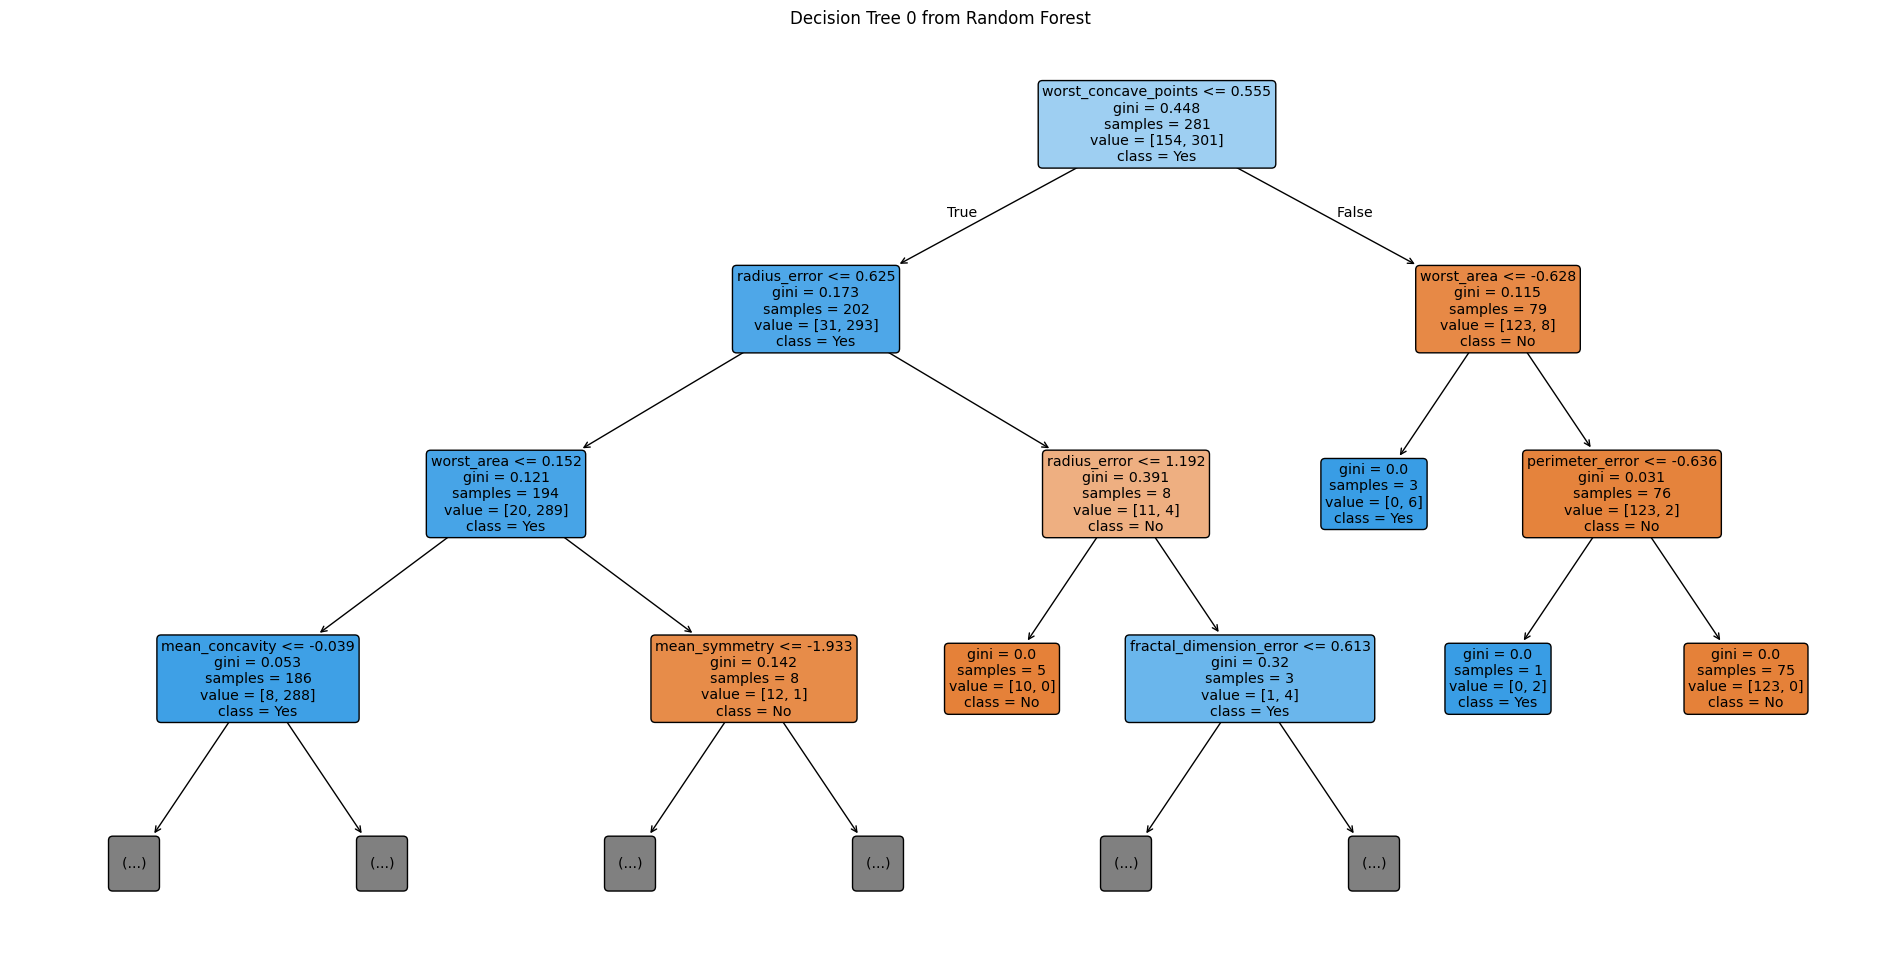

In [99]:
# Optional: get feature names from the fitted preprocessor
fitted_preprocessor = best_models['Random Forest'].named_steps['preprocessor']
try:
    feature_names = fitted_preprocessor.get_feature_names_out()
    # Clean names (remove pipeline prefixes)
    feature_names = [f.split("__")[-1] if "__" in f else f for f in feature_names]
except:
    feature_names = [f"f{i}" for i in range(X_train.shape[1])]

# Visualize the first tree
visualize_random_forest_tree(
    best_models,
    model_name='Random Forest',
    feature_names=feature_names,
    class_names=['No', 'Yes']  # update for your case
)

---
---
---
# **📊 CA3. Evaluation Score**

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, log_loss, average_precision_score, fbeta_score,
)

In [ ]:
def evaluate_models(models, X_test, y_test, beta=2):
    eval_results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        fbeta = fbeta_score(y_test, y_pred, beta=beta)
        pr_auc = average_precision_score(y_test, y_proba) if y_proba is not None else np.nan
        roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
        logloss = log_loss(y_test, y_proba) if y_proba is not None else np.nan

        eval_results.append({
            'Model': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            f'F-beta (beta={beta})': fbeta,
            'PR AUC': pr_auc,
            'ROC AUC': roc_auc,
            'Log Loss': logloss
        })

    eval_df = pd.DataFrame(eval_results)
    
    # Format display, works well in Jupyter Notebooks
    display(eval_df.style.format({
        'Accuracy': "{:.3f}",
        'Precision': "{:.3f}",
        'Recall': "{:.3f}",
        'F1 Score': "{:.3f}",
        f'F-beta (beta={beta})': "{:.3f}",
        'PR AUC': "{:.3f}",
        'ROC AUC': "{:.3f}",
        'Log Loss': "{:.3f}",
    }))
    
    return eval_df

In [ ]:
if ML_TYPE == 'classification':
    eval_df = evaluate_models(best_models, X_test, y_test)

---
---
---
# **📈 CA4. Evaluation Visualization**

---
---
## **📈 CA4.1. Confusion Matrices**

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
def plot_confusion_matrices(models, X_test, y_test):
    n = len(models)
    cols = 2
    rows = (n + 1) // cols
    plt.figure(figsize=(cols * 6, rows * 5))
    
    for i, (name, model) in enumerate(models.items(), 1):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]
        
        plt.subplot(rows, cols, i)
        sns.heatmap(
            cm_norm,
            annot=True,
            fmt='.3f',
            cmap='Blues',
            cbar=False,
            annot_kws={"size": 12}
        )
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix - {name}')
    
    plt.tight_layout()
    plt.show()

In [ ]:
if ML_TYPE == 'classification':
    plot_confusion_matrices(best_models, X_test, y_test)

---
---
## **📈 CA4.2. ROC and PR Curves**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

In [ ]:
def plot_combined_roc_pr(models, X_test, y_test):
    plt.figure(figsize=(14, 6))

    # ROC Curve subplot
    plt.subplot(1, 2, 1)
    for name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Combined ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Precision-Recall Curve subplot
    plt.subplot(1, 2, 2)
    for name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            precision, recall, _ = precision_recall_curve(y_test, y_proba)
            ap = average_precision_score(y_test, y_proba)
            plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Combined Precision-Recall Curve')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
if ML_TYPE == 'classification':
    plot_combined_roc_pr(best_models, X_test, y_test)

---
---
## **📈 CA4.3. Learning Curves**

In [ ]:
import numpy as np
from sklearn.model_selection import learning_curve, StratifiedKFold

In [ ]:
def plot_learning_curve(model, X_train, y_train, scoring='f1', cv_splits=5):
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes,
        cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42),
        scoring=scoring,
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='b')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='r')
    plt.plot(train_sizes, train_mean, 'o-', color='b', label='Training score')
    plt.plot(train_sizes, val_mean, 'o-', color='r', label='Validation score')
    plt.title(f'Learning Curve - {model.__class__.__name__}')
    plt.xlabel('Training examples')
    plt.ylabel('Score')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()        

In [ ]:
if ML_TYPE == 'classification':
    for name, model in best_models.items():
        print(f"📈 Plotting learning curve for: {name}")
        plot_learning_curve(model, X_train, y_train, scoring=CV_SCORING, cv_splits=CV)    

---
---
## **📈 CA4.4. Calibration Curves**

In [ ]:
from sklearn.calibration import calibration_curve

In [ ]:
def plot_calibration_curve(model, X_test, y_test, n_bins=10):
    if not hasattr(model, "predict_proba"):
        print(f"Model {model} has no predict_proba method.")
        return
    
    prob_pos = model.predict_proba(X_test)[:, 1]
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test, prob_pos, n_bins=n_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=model.__class__.__name__)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title(f'Calibration Curve - {model.__class__.__name__}')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
if ML_TYPE == 'classification':
    for name, model in best_models.items():
        print(f"📊 Plotting calibration curve for: {name}")
        plot_calibration_curve(model, X_test, y_test)

# **---------------------------------------------------------------------------------**
# **✅ CB. MODEL (REG) PIPELINE**

---
---
---
# **📙 CB1. Model Definitions**

- Define models and their hyperparameter grids for GridSearchCV

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor

In [ ]:
models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {}  # No hyperparameters to tune for basic LinearRegression
    },
    # 'Lasso Regression': {
    #     'model': Lasso(max_iter=10000),
    #     'params': {
    #         'model__alpha': [0.001, 0.01, 0.1, 1, 10]
    #     }
    # },
    # 'Ridge Regression': {
    #     'model': Ridge(max_iter=10000),
    #     'params': {
    #         'model__alpha': [0.001, 0.01, 0.1, 1, 10]
    #     }
    # },
    # 'ElasticNet Regression': {
    #     'model': ElasticNet(max_iter=10000),
    #     'params': {
    #         'model__alpha': [0.001, 0.01, 0.1, 1],
    #         'model__l1_ratio': [0.1, 0.5, 0.9]
    #     }
    # },
}

---
---
---
# **🔮 CB2. Model Training**

---
---
## **🔮 CB2.1. Set training parameters**

In [ ]:
CV = 5  # Number of cross-validation folds
CV_SCORING = 'neg_root_mean_squared_error'  # or 'r2', etc.

| **Scoring Name**                | **Description**                               | **When to Use**                                   |
| ------------------------------- | --------------------------------------------- | ------------------------------------------------- |
| `'r2'`                          | R² score (coefficient of determination)       | General-purpose metric, higher = better           |
| `'neg_mean_squared_error'`      | Negative Mean Squared Error (MSE)             | Penalizes large errors more heavily               |
| `'neg_root_mean_squared_error'` | Negative Root Mean Squared Error (RMSE)       | More interpretable than MSE (same unit as target) |
| `'neg_mean_absolute_error'`     | Negative Mean Absolute Error (MAE)            | Robust to outliers, interpretable                 |
| `'neg_median_absolute_error'`   | Negative Median Absolute Error                | Very robust to outliers                           |
| `'neg_mean_squared_log_error'`  | Negative MSLE                                 | Targets with exponential growth, non-negative     |
| `'explained_variance'`          | Proportion of variance explained by the model | Similar to R², but less sensitive to bias         |
| `'max_error'`                   | Worst-case (maximum absolute) error           | Want to minimize the worst prediction             |

⚠️ Notes:

- `neg_` prefix is used because GridSearchCV and cross_val_score maximize the score.
- So to minimize errors like MAE/MSE, scikit-learn negates them.
- To get actual error values after evaluation, multiply by -1.

---
---
## **🔮 CB2.2. Train and validate model**

In [ ]:
import time
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

In [ ]:
def train_and_tune_models(
    models_dict, X_train, y_train,
    preprocessor,
    cv_splits=5,
    scoring='r2',
    random_seed=42,
    n_jobs=-1,
    verbose=0
):
    training_results = []
    best_models = {}

    for name, mp in models_dict.items():
        print(f"\n🔧 Training regression model: {name}")
        
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', mp['model'])
        ])

        param_grid = mp.get('params', {})

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=KFold(n_splits=cv_splits, shuffle=True, random_state=random_seed),
            scoring=scoring,
            n_jobs=n_jobs,
            verbose=verbose
        )

        start_time = time.time()
        grid.fit(X_train, y_train)
        training_time = time.time() - start_time

        best_model = grid.best_estimator_
        best_models[name] = best_model

        val_score = grid.best_score_

        print(f"Best params: {grid.best_params_}")
        print(f"Training Time: {training_time:.2f}s")
        print(f"CV Score ({scoring}): {val_score:.3f}")

        training_results.append({
            'Model': name,
            'CV Score': val_score,
            'Training Time (s)': training_time,
            'Best Params': grid.best_params_
        })

    train_df = pd.DataFrame(training_results)
    
    print("\n📊 Regression Training Summary:")
    display(train_df.style.format({
        'CV Score': "{:.3f}",
        'Training Time (s)': "{:.2f}"
    }))
    
    return best_models, train_df

In [ ]:
if ML_TYPE == 'regression':
    best_models, train_summary = train_and_tune_models(
        models_dict=models,
        X_train=X_train,
        y_train=y_train,
        preprocessor=preprocessor,
        cv_splits=CV,
        scoring=CV_SCORING,
        random_seed=RANDOM_SEED,
        n_jobs=-1,
        verbose=0
    )

---
---
---
# **📊 CB3. Evaluation Score**

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    mean_squared_log_error,
    explained_variance_score,
    max_error
)

In [ ]:
def evaluate_models(models, X_test, y_test):
    eval_results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        med_ae = median_absolute_error(y_test, y_pred)
        msle = mean_squared_log_error(y_test, y_pred) if np.all(y_pred >= 0) and np.all(y_test >= 0) else np.nan
        evs = explained_variance_score(y_test, y_pred)
        max_err = max_error(y_test, y_pred)

        eval_results.append({
            'Model': name,
            'R2 Score': r2,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'Median AE': med_ae,
            'MSLE': msle,
            'Explained Variance': evs,
            'Max Error': max_err
        })

    eval_df = pd.DataFrame(eval_results)

    display(eval_df.style.format({
        'R2 Score': "{:.3f}",
        'MAE': "{:.3f}",
        'MSE': "{:.3f}",
        'RMSE': "{:.3f}",
        'Median AE': "{:.3f}",
        'MSLE': "{:.3f}",
        'Explained Variance': "{:.3f}",
        'Max Error': "{:.3f}"
    }))

    return eval_df

In [ ]:
if ML_TYPE == 'regression':
    eval_df = evaluate_models(best_models, X_test, y_test)

---
---
---
# **📈 CB4. Evaluation Visualization**

| Visualization                              | Description                                                            | What It Tells You                                              |
| ------------------------------------------ | ---------------------------------------------------------------------- | -------------------------------------------------------------- |
| **1. Predicted vs. Actual Plot**           | Scatter plot of predicted vs. actual values                            | How close predictions are to ground truth                      |
| **2. Residual Plot**                       | Residuals (errors) vs. predicted values                                | Non-random patterns = model misspecification                   |
| **3. Histogram of Residuals**              | Distribution of prediction errors                                      | Whether errors are centered around 0, and normally distributed |
| **4. Q-Q Plot (Quantile-Quantile)**        | Plot to compare residual distribution with normal distribution         | Whether residuals are approximately normal                     |
| **5. Learning Curve**                      | Training & validation performance vs. training size                    | Underfitting or overfitting trends                             |
| **6. Feature Importance**                  | Bar plot of model-derived importance values (tree models, Lasso, etc.) | Which features contribute most to predictions                  |
| **7. Error vs. Feature Plot**              | Residuals plotted against key features                                 | Heteroscedasticity, variable-specific bias                     |
| **8. Prediction Intervals (if available)** | Visualize uncertainty around predictions                               | Useful for risk-aware regression models                        |


---
---
## **📈 CB4.1. Predicted vs Actual Plot**

**_Is my model accurate?_**

- **What it does**: Plots predicted values against actual target values.

- **Use**: Quick visual check for alignment with the identity line.

- **Ideal outcome**: Points lie close to the 45° line (y = x).

In [ ]:
def plot_actual_vs_predicted(models, X_test, y_test):
    n = len(models)
    cols = 2
    rows = (n + 1) // cols
    plt.figure(figsize=(cols * 6, rows * 5))

    for i, (name, model) in enumerate(models.items(), 1):
        y_pred = model.predict(X_test)

        plt.subplot(rows, cols, i)
        sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')  # identity line

        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"Actual vs Predicted - {name}")
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [ ]:
if ML_TYPE == 'regression':
    plot_actual_vs_predicted(best_models, X_test, y_test)

---
---
## **📈 CB4.2. Residual Plot**

**_Are the residuals well-behaved?_**

- **What it does**: Plots residuals (`y_true` - `y_pred`) vs predicted values.

- **Use**: Detects bias, non-linearity, and heteroscedasticity.

- **Ideal outcome**: Residuals scattered randomly around 0.

In [ ]:
def plot_residuals(models, X_test, y_test):
    n = len(models)
    cols = 2
    rows = (n + 1) // cols
    plt.figure(figsize=(cols * 6, rows * 5))

    for i, (name, model) in enumerate(models.items(), 1):
        y_pred = model.predict(X_test)
        residuals = y_test - y_pred

        plt.subplot(rows, cols, i)
        sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
        plt.axhline(0, color='r', linestyle='--')  # horizontal zero line

        plt.xlabel("Predicted")
        plt.ylabel("Residuals (Actual - Predicted)")
        plt.title(f"Residual Plot - {name}")
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


In [ ]:
if ML_TYPE == 'regression':
    plot_residuals(best_models, X_test, y_test)

---
---
## **📈 CB4.3. Learning Curves**

**_Is the model improving with more data?_**

- **What it does**: Plots training and validation scores vs dataset size.

- **Use**: Diagnoses underfitting or overfitting.

- **Ideal outcome**: Validation and training scores converge and are high.

In [ ]:
from sklearn.model_selection import learning_curve, KFold
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(model, X_train, y_train, scoring='r2', cv_splits=5):
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes,
        cv=KFold(n_splits=cv_splits, shuffle=True, random_state=42),
        scoring=scoring,
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation score')
    
    plt.title(f'Learning Curve - {model.__class__.__name__}', fontsize=14)
    plt.xlabel('Training examples', fontsize=12)
    plt.ylabel(scoring.upper(), fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


In [ ]:
if ML_TYPE == 'regression':
    for name, model in best_models.items():
        print(f"📈 Plotting learning curve for: {name}")
        plot_learning_curve(model, X_train, y_train, scoring=CV_SCORING, cv_splits=CV)    

---
---
## **📈 CB4.4. Q-Q Plot**

**_Do residuals follow a normal distribution?_**

- **What it does**: Compares residual quantiles to normal distribution quantiles.

- **Use**: Assesses whether residuals are normally distributed (important for some models).

- **Ideal outcome**: Points lie close to the diagonal line.

In [ ]:
import scipy.stats as stats

def plot_qq_plots(models, X_test, y_test):
    n = len(models)
    cols = 2
    rows = (n + 1) // cols
    plt.figure(figsize=(cols * 6, rows * 5))

    for i, (name, model) in enumerate(models.items(), 1):
        y_pred = model.predict(X_test)
        residuals = y_test - y_pred

        plt.subplot(rows, cols, i)
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title(f"QQ Plot of Residuals - {name}")
        plt.xlabel("Theoretical Quantiles")
        plt.ylabel("Sample Quantiles")
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_qq_plots(best_models, X_test, y_test)

# **---------------------------------------------------------------------------------**
# **✅ D. MODEL INTERPRETABILITY**

| Method             | Global or Local | Model Agnostic?  | Pros                           | Cons                        |
| ------------------ | --------------- | ---------------- | ------------------------------ | --------------------------- |
| Feature Importance | Global          | Sometimes        | Fast, intuitive                | Can be biased, no direction |
| SHAP Values        | Local & Global  | Yes              | Consistent, additive, detailed | Computationally expensive   |
| Partial Dependence | Global          | Yes              | Shows feature effect shape     | Assumes independence        |
| ICE Plots          | Local           | Yes              | Captures individual effects    | Can be noisy                |
| LIME               | Local           | Yes              | Model-agnostic                 | Can be unstable             |
| Coefficients       | Global          | No (linear only) | Direct, simple                 | Only linear models          |


---
---
---
# **🏆 D1. Feature Importance / Coefficients**

**Feature Importance (For tree-based models)**

- **What:** Measures how much each feature contributes to a model’s predictions, often aggregated over the entire dataset.

- **Where:** Common in tree-based models like Random Forest, XGBoost, LightGBM.

- **Types:**

  - Gini importance or Mean Decrease in Impurity (built-in for trees)
  - Permutation Importance (model-agnostic, measures drop in performance when feature is shuffled)

- **Pros:** Fast, easy to compute, intuitive.

- **Cons:** Can be biased (e.g., towards high cardinality features), doesn’t explain direction or interaction.

**Coefficients (For linear models)**

- **What:** Direct interpretation of coefficients in linear/logistic regression.

- **Pros:** Simple, direct feature effect (with sign).

- **Cons:** Only works for linear models; can be misleading with multicollinearity.

In [ ]:
import pandas as pd
import numpy as np

def get_feature_importance_from_best_models(best_models, top_n=20):
    """
    Extracts feature importances or coefficients from best_models.

    Parameters:
    - best_models: dict output from train_and_tune_models()
    - top_n: number of top features to return per model

    Returns:
    - Dictionary: model name -> DataFrame with top features and their importance
    """

    def get_feature_names(fitted_preprocessor):
        """Extract feature names from fitted ColumnTransformer."""
        if not hasattr(fitted_preprocessor, 'transformers_'):
            raise ValueError("Preprocessor is not fitted. Pass a fitted ColumnTransformer.")
        
        output_features = []
        for name, transformer, columns in fitted_preprocessor.transformers_:
            if name != 'remainder':
                if hasattr(transformer, 'get_feature_names_out'):
                    names = transformer.get_feature_names_out(columns)
                else:
                    names = columns
                output_features.extend(names)
        return output_features

    # Extract fitted preprocessor from any trained pipeline
    fitted_preprocessor = list(best_models.values())[0].named_steps['preprocessor']
    feature_names = get_feature_names(fitted_preprocessor)
    
    importance_results = {}

    for model_name, pipeline in best_models.items():
        print(f"\n🔍 Extracting feature importances for: {model_name}")
        estimator = pipeline.named_steps['model']

        if hasattr(estimator, 'feature_importances_'):
            importances = estimator.feature_importances_
        elif hasattr(estimator, 'coef_'):
            importances = estimator.coef_
            if len(importances.shape) > 1:
                importances = importances[0]
        else:
            print(f"⚠️  {model_name} does not support feature importances or coefficients.")
            continue

        importances = pd.Series(np.abs(importances), index=feature_names)
        top_features = importances.sort_values(ascending=False).head(top_n)
        importance_results[model_name] = top_features.reset_index().rename(columns={'index': 'Feature', 0: 'Importance'})

    return importance_results

In [ ]:
importance_dict = get_feature_importance_from_best_models(best_models)
importance_dict['Logistic Regression']

---
---
---
# **🔢 D2. SHAP Values**

**What:** A game-theoretic approach assigning each feature a contribution value (positive or negative) per prediction.

**Where:** Model-agnostic; has efficient implementations for trees (TreeSHAP).

**Pros:** Explains individual predictions and global behavior; consistent, additive explanations.

**Cons:** Computationally expensive for large datasets/models (especially KernelSHAP).

| Plot Type        | Use Case                                        | Visual Style       | Scope                       |
| ---------------- | ----------------------------------------------- | ------------------ | --------------------------- |
| Summary Plot     | Global feature importance + effect distribution | Dot plot (scatter) | Dataset-wide                |
| Bar Plot         | Global feature importance                       | Horizontal bars    | Dataset-wide                |
| Dependence Plot  | Feature effect + interactions                   | Scatter            | Single feature              |
| Force Plot       | Individual prediction explanation               | Interactive force  | Single/multiple predictions |
| Decision Plot    | Cumulative build-up of prediction               | Line plot          | Single/multiple predictions |
| Waterfall Plot   | Stepwise single prediction explanation          | Waterfall chart    | Single prediction           |
| Heatmap          | Feature contributions across samples            | Heatmap            | Multiple samples            |
| Interaction Plot | Pairwise feature interaction                    | Scatter/dot plot   | Feature pairs               |


In [ ]:
import os
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["LOKY_MAX_CPU_COUNT"] = "4"

def explain_models_with_shap(
    best_models,
    X_sample,
    top_n=10,
    show_summary=False,
    show_bar=False,
    show_dependence=False,
    show_force=False,
    show_decision=False,
    show_waterfall=False,
    show_heatmap=False,
    show_interaction=False
):
    """
    Generate SHAP plots for all models in best_models.

    Returns:
    - dict: model name -> pandas DataFrame with all SHAP values
    """
    shap_values_dict = {}

    for model_name, pipeline in best_models.items():
        print(f"\n🔍 Explaining model: {model_name}")

        model = pipeline.named_steps['model']
        preprocessor = pipeline.named_steps['preprocessor']
        X_processed = preprocessor.transform(X_sample)

        # Get cleaned feature names
        try:
            feature_names = preprocessor.get_feature_names_out()
            feature_names = [f.split("__")[-1] if "__" in f else f for f in feature_names]
        except:
            feature_names = [f"f{i}" for i in range(X_processed.shape[1])]

        try:
            lname = model_name.lower()
            if any(x in lname for x in ['randomforest', 'xgb', 'lightgbm', 'catboost']):
                explainer = shap.TreeExplainer(model)
                shap_values = explainer.shap_values(X_processed)
            elif any(x in lname for x in ['logisticregression', 'linearregression']):
                explainer = shap.LinearExplainer(model, X_processed, feature_perturbation="interventional")
                shap_values = explainer.shap_values(X_processed)
            else:
                explainer = shap.KernelExplainer(model.predict, shap.kmeans(X_processed, 10))
                shap_values = explainer.shap_values(X_processed, nsamples=100)
        except Exception as e:
            print(f"  ⚠️ Could not create SHAP explainer for {model_name}: {e}")
            continue

        # Handle multi-class outputs
        shap_vals = shap_values[0] if isinstance(shap_values, list) else shap_values

        # Compute mean abs SHAP values
        mean_abs_shap = np.abs(shap_vals).mean(axis=0)
        df_all_shap = pd.DataFrame({
            "feature": feature_names,
            "mean_abs_shap": mean_abs_shap
        }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

        shap_values_dict[model_name] = df_all_shap

        # === Optional Plots ===
        try:
            if show_summary:
                print("📌 Summary Plot:")
                shap.summary_plot(shap_vals, X_processed, feature_names=feature_names, max_display=top_n)

            if show_bar:
                print("📊 Bar Plot:")
                shap.plots.bar(shap.Explanation(values=shap_vals, data=X_processed, feature_names=feature_names))

            if show_dependence:
                print("📈 Dependence Plot (top feature):")
                top_feature = df_all_shap['feature'].iloc[0]
                shap.dependence_plot(top_feature, shap_vals, X_processed, feature_names=feature_names)

            if show_force:
                print("🧲 Force Plot (first instance):")
                shap.initjs()
                display(shap.force_plot(explainer.expected_value, shap_vals[0], X_processed[0], feature_names=feature_names))

            if show_decision:
                print("🧠 Decision Plot (first 5):")
                shap.decision_plot(explainer.expected_value, shap_vals[:5], feature_names=feature_names)

            if show_waterfall:
                print("🌊 Waterfall Plot (first instance):")
                shap.plots.waterfall(shap.Explanation(values=shap_vals[0], base_values=explainer.expected_value, data=X_processed[0], feature_names=feature_names))

            if show_heatmap:
                print("🔥 Heatmap:")
                shap.plots.heatmap(shap.Explanation(values=shap_vals, data=X_processed, feature_names=feature_names))

            if show_interaction:
                print("🔄 Interaction Plot (top 2 features):")
                top_feats = df_all_shap['feature'].values[:2]
                shap.dependence_plot(
                    top_feats[0],
                    shap_vals,
                    X_processed,
                    interaction_index=top_feats[1],
                    feature_names=feature_names
                )
        except Exception as e:
            print(f"  ⚠️ Plotting failed for {model_name}: {e}")

    return shap_values_dict

In [ ]:
shap_results = explain_models_with_shap(
    best_models,
    X_test,
    top_n=15,
    show_summary=False,
    show_bar=False,
    show_dependence=False,
    show_force=False,
    show_decision=False,
    show_waterfall=False,
    show_heatmap=False,
    show_interaction=False
)

# View full SHAP table
shap_results['Logistic Regression'].head()

# **---------------------------------------------------------------------------------**
# **✅ E. MODEL DEPLOYMENT**


---
---
---

# **---------------------------------------------------------------------------------**